# 법인카드 정산 자동화 · 이상거래 탐지를 위한 EDA

**분석 대상**: 국내 신용카드 승인거래 데이터 (2021~2024년, 분기별 16개 파일, 약 173만 건)
**분석 목적**: 법인카드 정산 자동화 및 이상거래 탐지 프로젝트를 위한 데이터 구조 파악, 데이터 품질 점검, 이상거래 패턴 탐색, Feature Engineering 및 모델링 방향 도출

---
### 데이터셋 개요
- 파일 형태: `21-2_카드데이터_{연도}_{분기}.csv`, 2021년 1분기 ~ 2024년 4분기 (총 16개 파일)
- 컬럼 수: 32개 (거래 정보, 카드 정보, 가맹점 정보, 이상거래 라벨 포함)
- 타겟 컬럼: `이상거래여부` (0=정상, 1=이상거래), `이상거래유형` (이상거래인 경우의 세부 유형 코드)

> ⚠️ **실행 안내**: 이 노트북은 `DATA_DIR` 경로에 있는 `21-2_카드데이터_*.csv` 파일들을 읽습니다. 노트북과 CSV 파일을 같은 폴더에 두면 별도 수정 없이 바로 실행됩니다. 파일 위치가 다르다면 2절의 `DATA_DIR` 변수만 수정하면 됩니다.


## 1. 라이브러리 Import

분석에 필요한 라이브러리를 불러오고, 그래프 스타일과 한글 폰트를 설정합니다. 한글 폰트를 설정하지 않으면 컬럼명·범주값이 모두 한글인 이 데이터셋의 그래프에서 텍스트가 깨져(글자가 네모 박스로) 보이므로 필수 설정입니다.


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from scipy import stats
import glob
import os
import warnings

warnings.filterwarnings('ignore')

# ---- 그래프 스타일 설정 ----
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# ---- 한글 폰트 설정 (시스템에 설치된 CJK 폰트를 자동 탐색) ----
def set_korean_font():
    candidates = ['NanumGothic', 'Malgun Gothic', 'AppleGothic',
                   'Noto Sans CJK KR', 'Noto Sans CJK JP', 'Noto Sans KR']
    available = {f.name for f in fm.fontManager.ttflist}
    for name in candidates:
        if name in available:
            plt.rcParams['font.family'] = name
            print(f"한글 폰트 설정 완료: {name}")
            return name
    print("경고: 한글 폰트를 찾지 못했습니다. 그래프의 한글이 깨질 수 있습니다.")
    return None

set_korean_font()
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)

print("라이브러리 로드 완료")


한글 폰트 설정 완료: Malgun Gothic
라이브러리 로드 완료


## 2. 데이터 불러오기

분기별로 나뉜 16개 파일을 하나로 통합합니다. `load_transaction_data()` 함수는 폴더 내 CSV/XLSX 파일을 자동으로 인식해 모두 읽어 합칩니다 (확장자 자동 판별 → 함수화).


In [2]:

DATA_DIR = '../.data/train'  # 노트북과 CSV가 다른 폴더에 있다면 이 경로를 수정하세요.
FILE_PATTERN = '21-2_카드데이터_*'

def load_transaction_data(data_dir=DATA_DIR, pattern=FILE_PATTERN):
    '''data_dir 내 csv/xlsx 파일을 자동 인식하여 하나의 DataFrame으로 통합.'''
    csv_files = sorted(glob.glob(os.path.join(data_dir, pattern + '.csv')))
    xlsx_files = sorted(glob.glob(os.path.join(data_dir, pattern + '.xlsx')))

    frames = []
    if csv_files:
        for f in csv_files:
            frames.append(pd.read_csv(f, encoding='utf-8', low_memory=False))
        print(f"CSV {len(csv_files)}개 파일 로드")
    elif xlsx_files:
        for f in xlsx_files:
            frames.append(pd.read_excel(f))
        print(f"XLSX {len(xlsx_files)}개 파일 로드")
    else:
        raise FileNotFoundError(
            f"'{data_dir}' 경로에서 '{pattern}' 패턴의 csv/xlsx 파일을 찾지 못했습니다. "
            "DATA_DIR 변수를 데이터가 있는 경로로 수정해주세요."
        )

    df = pd.concat(frames, ignore_index=True)
    return df

df = load_transaction_data()
print("통합 데이터 shape:", df.shape)


CSV 16개 파일 로드
통합 데이터 shape: (1735885, 32)


데이터를 미리보기(head), 구조(info), 요약통계(describe)로 확인합니다.

In [3]:

display(df.head())


,기준년월,승인일자,승인SEQ,승인시간대,카드KEY,통합승인금액,개인법인구분코드_회원,국내해외여부,카드이용한도금액,가맹점광역시도코드,이상거래여부,이상거래유형,이상거래설명,연령,남녀구분코드,승인거래코드,승인발생경로코드,가맹점승인업종코드,가맹점누적매출금액_구간화,개인법인구분코드_가맹점,가맹점여부_신규,인터넷판매여부,경과일수_최종이용일자,가맹점상태코드,가맹점형태구분코드,로고구분코드,일시불할부구분코드,전월_매출건수,카드구분코드,할부가능개월수,가맹점KEY,전월_매출금액
0,202102,20210207,2,9,CD001231,8000,1.0,0,10000000.0,13.0,0,NaN,NaN,4.0,1,00,C,2307,2,1,0.0,0.0,32.0,30.0,00,2,A,48.0,1,24.0,ST001180,1350000.0
1,202102,20210219,17,17,CD000104,19000,1.0,0,0.0,13.0,0,NaN,NaN,2.0,2,00,C,4402,2,1,0.0,0.0,33.0,30.0,00,2,A,55.0,1,24.0,ST000266,1894000.0
2,202101,20210111,8,12,CD000965,8000,1.0,0,5000000.0,9.0,0,NaN,NaN,5.0,2,00,C,5101,2,_,0.0,0.0,32.0,30.0,00,1,A,53.0,1,24.0,ST000375,1575000.0
3,202103,20210328,58,16,CD000424,4000,1.0,0,0.0,9.0,0,NaN,NaN,5.0,2,10,C,2502,1,1,0.0,0.0,34.0,30.0,00,3,A,377.0,1,24.0,ST000019,1990000.0
4,202103,20210305,8,13,CD000059,8000,1.0,0,10000000.0,2.0,0,NaN,NaN,3.0,1,00,C,9201,3,2,0.0,0.0,32.0,30.0,00,2,A,43247.0,1,24.0,ST001320,1247000.0


In [4]:

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1735885 entries, 0 to 1735884
Data columns (total 32 columns):
 #   Column         Dtype  
---  ------         -----  
 0   기준년월           int64  
 1   승인일자           int64  
 2   승인SEQ          int64  
 3   승인시간대          int64  
 4   카드KEY          str    
 5   통합승인금액         int64  
 6   개인법인구분코드_회원    float64
 7   국내해외여부         int64  
 8   카드이용한도금액       float64
 9   가맹점광역시도코드      float64
 10  이상거래여부         int64  
 11  이상거래유형         float64
 12  이상거래설명         str    
 13  연령             float64
 14  남녀구분코드         str    
 15  승인거래코드         str    
 16  승인발생경로코드       str    
 17  가맹점승인업종코드      str    
 18  가맹점누적매출금액_구간화  int64  
 19  개인법인구분코드_가맹점   str    
 20  가맹점여부_신규       float64
 21  인터넷판매여부        float64
 22  경과일수_최종이용일자    float64
 23  가맹점상태코드        float64
 24  가맹점형태구분코드      str    
 25  로고구분코드         int64  
 26  일시불할부구분코드      str    
 27  전월_매출건수        float64
 28  카드구분코드         int64  
 29  할부가능개월수        float64
 3

In [5]:

df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
기준년월,1735885.0,NaN,NaN,NaN,202253.478234,111.774377,202101.0,202112.0,202212.0,202312.0,202412.0
승인일자,1735885.0,NaN,NaN,NaN,20225363.500709,11177.39814,20210101.0,20211218.0,20221214.0,20231217.0,20241231.0
승인SEQ,1735885.0,NaN,NaN,NaN,27.315239,26.008363,1.0,8.0,20.0,39.0,306.0
승인시간대,1735885.0,NaN,NaN,NaN,14.760374,3.441025,0.0,12.0,15.0,18.0,23.0
카드KEY,1735885,2636,CD000193,7907,NaN,NaN,NaN,NaN,NaN,NaN,NaN
통합승인금액,1735885.0,NaN,NaN,NaN,62545.968195,270529.666987,0.0,8000.0,9000.0,10000.0,2812000.0
개인법인구분코드_회원,1735544.0,NaN,NaN,NaN,1.097417,0.296524,1.0,1.0,1.0,1.0,2.0
국내해외여부,1735885.0,NaN,NaN,NaN,0.0084,0.091268,0.0,0.0,0.0,0.0,1.0
카드이용한도금액,1735746.0,NaN,NaN,NaN,4496807.136528,3966967.705321,0.0,1000000.0,5000000.0,10000000.0,10000000.0
가맹점광역시도코드,1709946.0,NaN,NaN,NaN,7.865123,4.59098,1.0,3.0,9.0,11.0,17.0



**해석**
- 16개 분기 파일이 모두 32개 컬럼으로 동일한 스키마를 가지고 있어 문제없이 통합되었습니다 (총 약 173만 행).
- `기준년월`, `승인일자`는 정수(YYYYMM, YYYYMMDD) 형태로 저장되어 있어 날짜 분석 전 변환이 필요합니다.
- `통합승인금액`(거래금액)의 평균은 중앙값보다 훨씬 커서(우측 꼬리) 왜도가 큰 분포일 가능성이 높습니다 — 4절에서 자세히 확인합니다.
- `카드이용한도금액`은 unique 값이 매우 적어(뒤에서 확인) 사실상 연속형이 아니라 몇 개의 구간으로 이루어진 범주형에 가깝습니다.


## 3. 데이터 품질 분석

결측치, 중복값, 데이터 타입, 컬럼별 고유값 개수, 그리고 이 데이터 특유의 "이상한 값"(플레이스홀더 인코딩)을 점검합니다.


In [6]:

def missing_value_report(df):
    '''컬럼별 결측치 개수/비율, dtype, 고유값 개수를 하나의 표로 정리.'''
    report = pd.DataFrame({
        'dtype': df.dtypes.astype(str),
        '결측치_개수': df.isnull().sum(),
        '결측치_비율(%)': (df.isnull().sum() / len(df) * 100).round(2),
        'unique_개수': df.nunique(),
    })
    return report.sort_values('결측치_개수', ascending=False)

report = missing_value_report(df)
report


,dtype,결측치_개수,결측치_비율(%),unique_개수
이상거래설명,str,1671878,96.31,24729
이상거래유형,float64,1671878,96.31,4
가맹점광역시도코드,float64,25939,1.49,17
개인법인구분코드_가맹점,str,25939,1.49,3
가맹점여부_신규,float64,25939,1.49,2
인터넷판매여부,float64,25939,1.49,2
전월_매출건수,float64,13673,0.79,114147
전월_매출금액,float64,12886,0.74,310799
할부가능개월수,float64,11336,0.65,9
가맹점형태구분코드,str,10929,0.63,3



**해석**: `이상거래유형`은 이상거래(`이상거래여부`=1, 전체의 약 3.7%)인 행에서만 값이 채워지는 컬럼이므로, 나머지 96.3%(정상 거래)에서는 결측치로 나타나는 것이 정상입니다. `개인법인구분코드_회원`, `연령`, `남녀구분코드` 등은 결측치가 100~300여 건 수준으로 미미합니다. 반면 `가맹점광역시도코드`, `개인법인구분코드_가맹점`, `가맹점여부_신규` 등 가맹점 관련 컬럼은 결측치가 상대적으로 많습니다.


In [7]:

dup_count = df.duplicated().sum()
print(f"완전 중복 행 개수: {dup_count:,} 건 ({dup_count/len(df)*100:.4f}%)")

zero_amount = (df['통합승인금액'] == 0).sum()
print(f"거래금액이 0원인 행: {zero_amount:,} 건")

neg_cnt = (df['전월_매출건수'] < 0).sum()
neg_amt = (df['전월_매출금액'] < 0).sum()
print(f"전월_매출건수가 음수인 행: {neg_cnt:,} 건")
print(f"전월_매출금액이 음수인 행: {neg_amt:,} 건")


완전 중복 행 개수: 0 건 (0.0000%)
거래금액이 0원인 행: 2,509 건
전월_매출건수가 음수인 행: 432 건
전월_매출금액이 음수인 행: 936 건


In [8]:
# 0원 거래 및 전월 매출 음수 값이 실제로 이상거래와 얼마나 관련되는지 확인
zero_flag = df['통합승인금액'] == 0
print(f"통합승인금액=0원 거래의 이상거래 비율: {df.loc[zero_flag, '이상거래여부'].mean()*100:.3f}% "
      f"(그 외 거래: {df.loc[~zero_flag, '이상거래여부'].mean()*100:.3f}%)")
print()

neg_cnt_flag = df['전월_매출건수'] < 0
print(f"전월_매출건수<0 거래의 이상거래 비율: {df.loc[neg_cnt_flag, '이상거래여부'].mean()*100:.3f}% "
      f"(그 외: {df.loc[~neg_cnt_flag, '이상거래여부'].mean()*100:.3f}%)")

neg_amt_flag = df['전월_매출금액'] < 0
print(f"전월_매출금액<0 거래의 이상거래 비율: {df.loc[neg_amt_flag, '이상거래여부'].mean()*100:.3f}% "
      f"(그 외: {df.loc[~neg_amt_flag, '이상거래여부'].mean()*100:.3f}%)")


통합승인금액=0원 거래의 이상거래 비율: 0.518% (그 외 거래: 3.692%)

전월_매출건수<0 거래의 이상거래 비율: 11.574% (그 외: 3.685%)
전월_매출금액<0 거래의 이상거래 비율: 4.594% (그 외: 3.687%)


이 데이터셋은 문자열 컬럼에 결측치(NaN)와는 별도로 `'_'` 라는 플레이스홀더 값이 사용됩니다. 특히 이 플레이스홀더는 **법인카드(개인법인구분코드_회원=2)** 거래에서 개인 인적 정보(성별, 연령 등)가 해당되지 않을 때 사용되는 패턴으로 보여, 프로젝트 맥락(법인카드 정산)에서 중요한 신호입니다.

In [9]:

def underscore_placeholder_report(df):
    '''문자열 컬럼에서 '_' 플레이스홀더 값의 개수를 집계.'''
    rows = []
    for col in df.columns:
        if pd.api.types.is_string_dtype(df[col]):
            n = (df[col] == '_').sum()
            if n > 0:
                rows.append({'컬럼': col, "'_' 개수": n, "비율(%)": round(n / len(df) * 100, 2)})
    return pd.DataFrame(rows).sort_values("'_' 개수", ascending=False)

underscore_report = underscore_placeholder_report(df)
underscore_report


,컬럼,'_' 개수,비율(%)
0,남녀구분코드,169071,9.74
4,개인법인구분코드_가맹점,161907,9.33
5,가맹점형태구분코드,94015,5.42
6,일시불할부구분코드,10228,0.59
3,가맹점승인업종코드,2124,0.12
1,승인거래코드,870,0.05
2,승인발생경로코드,805,0.05


In [10]:

# '_' 플레이스홀더가 법인카드(개인법인구분코드_회원=2)와 얼마나 겹치는지 교차 확인
print("남녀구분코드='_' 인 거래의 개인법인구분코드_회원 분포:")
print(df.loc[df['남녀구분코드'] == '_', '개인법인구분코드_회원'].value_counts(dropna=False))
print()
print("전체 법인(2.0) 카드 거래 건수:", (df['개인법인구분코드_회원'] == 2.0).sum())


남녀구분코드='_' 인 거래의 개인법인구분코드_회원 분포:
개인법인구분코드_회원
2.0    169071
Name: count, dtype: int64



전체 법인(2.0) 카드 거래 건수: 169071


In [11]:

# 카드이용한도금액: unique 값이 4개뿐 -> 사실상 구간화된 범주형 변수
print("카드이용한도금액 고유값:", sorted(df['카드이용한도금액'].dropna().unique()))
print()
limit_by_type = pd.crosstab(df['카드이용한도금액'], df['개인법인구분코드_회원'])
limit_by_type.columns = ['개인(1.0)', '법인(2.0)']
limit_by_type


카드이용한도금액 고유값: [np.float64(0.0), np.float64(1000000.0), np.float64(5000000.0), np.float64(10000000.0)]



,개인(1.0),법인(2.0)
카드이용한도금액,,
0.0,225020,165093
1000000.0,349931,432
5000000.0,498937,467
10000000.0,492585,3079



**해석 (이상한 값 탐색 결과)**
1. **완전 중복 행은 없습니다.** 승인SEQ 등으로 거래가 고유하게 식별되고 있습니다.
2. **`남녀구분코드`, `개인법인구분코드_가맹점`, `가맹점형태구분코드`, `일시불할부구분코드` 등에 존재하는 `'_'` 값은 사실상 "해당없음/미기재"를 의미하는 결측치입니다.** 특히 `남녀구분코드='_'`인 거래는 100% `개인법인구분코드_회원=2.0`(법인카드)과 일치합니다 — 즉 법인카드는 개인 인적정보 필드가 아예 채워지지 않는 구조이며, `.isnull()`만으로는 이 결측을 잡아낼 수 없으므로 전처리 시 `'_'`를 명시적으로 NaN 처리해야 합니다.
3. **`카드이용한도금액`은 0 / 100만 / 500만 / 1,000만원, 단 4개 값만 존재**하는 구간화 변수입니다. 특히 법인카드 거래의 대다수(약 98%)가 `0원`으로 기록되어 있어, 법인카드에 대해서는 이 필드가 사실상 신뢰할 수 없는 값(한도 미기재)임을 시사합니다. **법인카드 정산 프로젝트에서 이 필드를 한도 소진율 등의 피처로 쓰려면 법인 카드 세그먼트에서는 별도 처리가 필요**합니다.
4. **`통합승인금액=0원` 거래**(2,509건)의 실제 이상거래 비율은 0.52%로 전체 평균(3.69%)보다 오히려 낮습니다 — 단순 취소·인증성 거래일 가능성이 높고, 이상거래 신호로 보기는 어렵습니다.
5. **`전월_매출건수`가 음수인 거래**(432건)의 이상거래 비율은 11.57%로 전체 평균의 3배 이상이며, `전월_매출금액` 음수(936건)도 4.59%로 다소 높습니다 — 단순 데이터 입력 오류로 치부하기보다, 특히 `전월_매출건수` 음수는 그 자체로 유의미한 위험 신호일 가능성이 있어 제외보다는 별도 플래그 피처로 남겨두는 것을 권장합니다.


## 4. 수치형 변수 분석

실질적으로 연속형인 5개 변수(`통합승인금액`, `카드이용한도금액`, `전월_매출건수`, `전월_매출금액`, `경과일수_최종이용일자`)에 대해 히스토그램·박스플롯·KDE·왜도·첨도를 함수화하여 일괄 출력합니다.


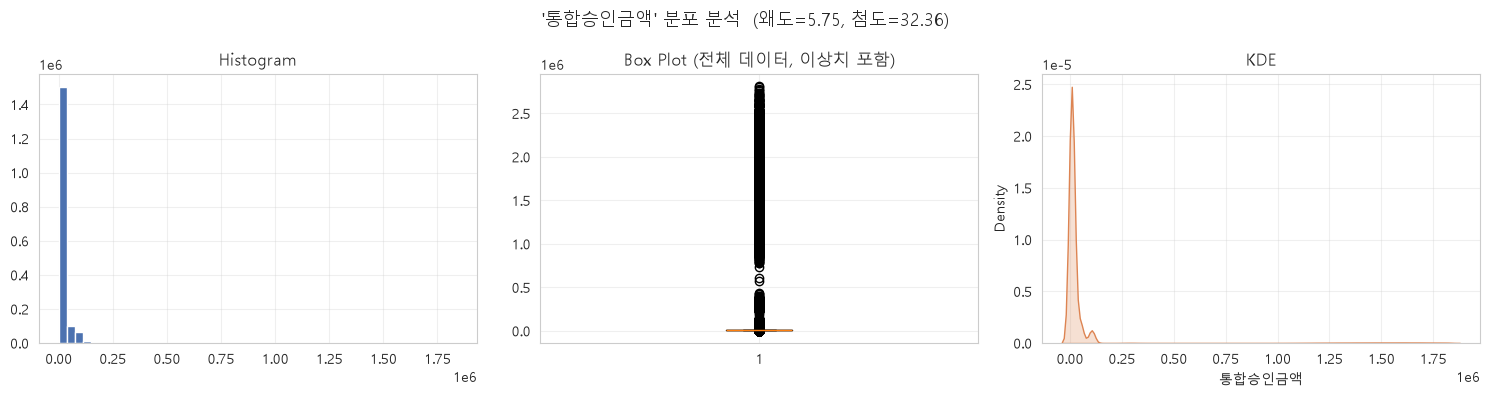

  - 결측 제외 건수: 1,735,885 / 평균: 62,546.0 / 중앙값: 9,000.0
  - IQR 기준 상단 이상치(> 13,000.0) 개수: 428,564 건 (24.69%)



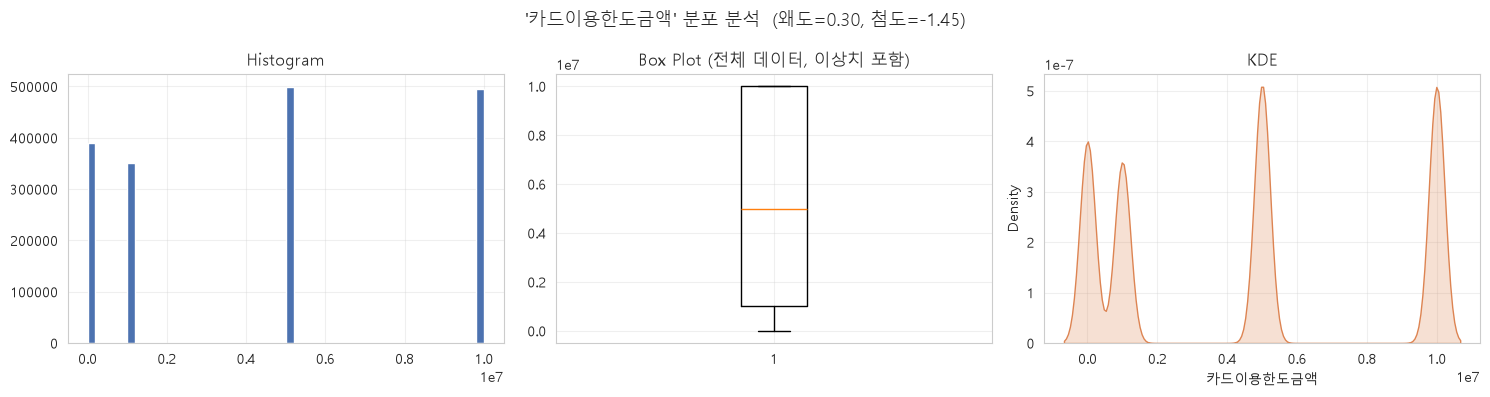

  - 결측 제외 건수: 1,735,746 / 평균: 4,496,807.1 / 중앙값: 5,000,000.0
  - IQR 기준 상단 이상치(> 23,500,000.0) 개수: 0 건 (0.00%)



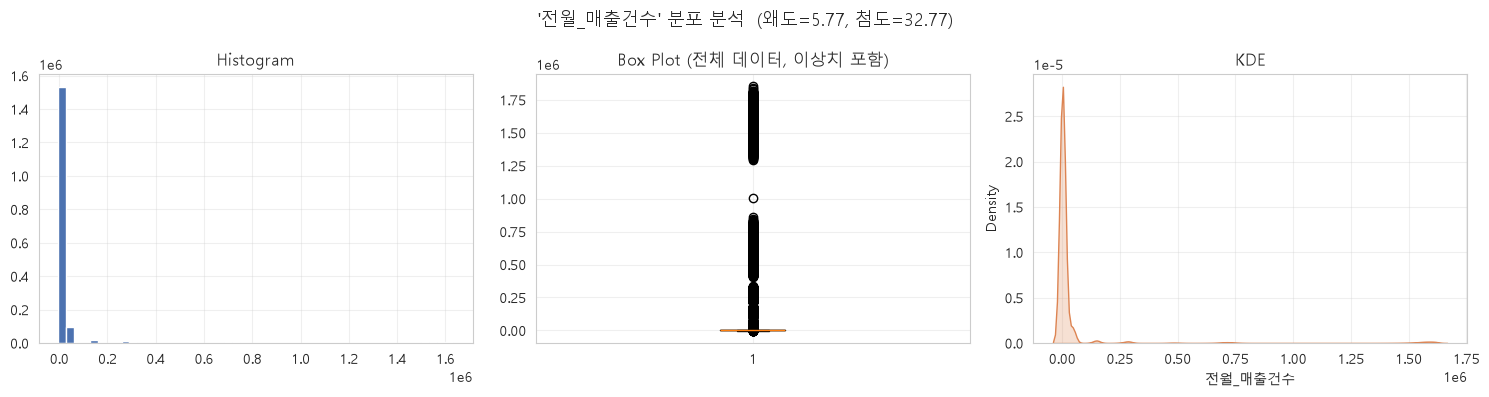

  - 결측 제외 건수: 1,722,212 / 평균: 50,262.4 / 중앙값: 338.0
  - IQR 기준 상단 이상치(> 3,334.5) 개수: 365,035 건 (21.20%)



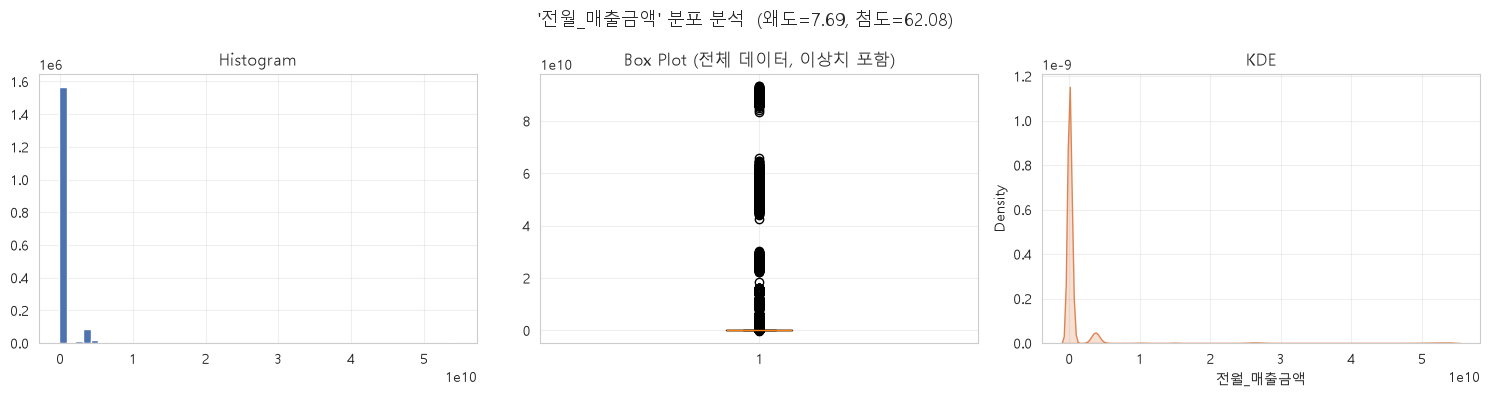

  - 결측 제외 건수: 1,722,999 / 평균: 1,185,200,113.2 / 중앙값: 1,871,000.0
  - IQR 기준 상단 이상치(> 26,675,500.0) 개수: 400,792 건 (23.26%)



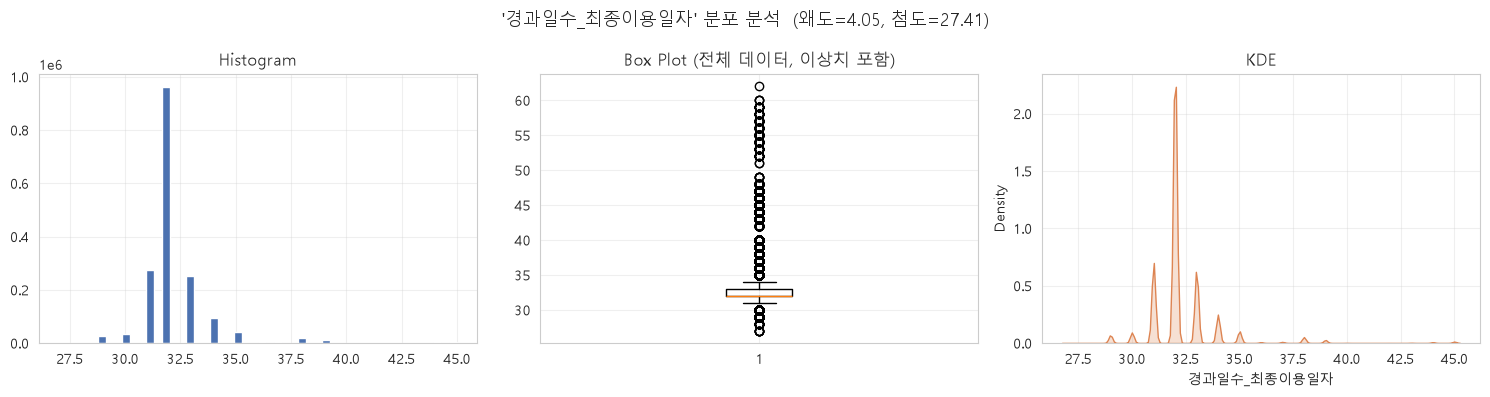

  - 결측 제외 건수: 1,735,719 / 평균: 32.3 / 중앙값: 32.0
  - IQR 기준 상단 이상치(> 34.5) 개수: 90,614 건 (5.22%)



In [12]:

NUMERIC_COLS = ['통합승인금액', '카드이용한도금액', '전월_매출건수', '전월_매출금액', '경과일수_최종이용일자']

def analyze_numeric(df, col, clip_quantile=0.995):
    '''히스토그램/박스플롯/KDE + 왜도/첨도 출력. 극단값 때문에 그래프가 눌리는 것을 막기 위해
    시각화에서만 상위 clip_quantile 분위수로 x축을 제한한다 (통계치는 원본 기준).'''
    data = df[col].dropna()
    skewness = stats.skew(data)
    kurt = stats.kurtosis(data)

    upper = data.quantile(clip_quantile)
    plot_data = data[data <= upper]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(f"'{col}' 분포 분석  (왜도={skewness:.2f}, 첨도={kurt:.2f})", fontsize=13)

    axes[0].hist(plot_data, bins=50, color='#4C72B0', edgecolor='white')
    axes[0].set_title('Histogram')

    axes[1].boxplot(data, vert=True, showfliers=True)
    axes[1].set_title('Box Plot (전체 데이터, 이상치 포함)')

    sns.kdeplot(plot_data, ax=axes[2], color='#DD8452', fill=True)
    axes[2].set_title('KDE')

    plt.tight_layout()
    plt.show()

    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    iqr = q3 - q1
    outlier_upper = q3 + 1.5 * iqr
    n_outliers = (data > outlier_upper).sum()
    print(f"  - 결측 제외 건수: {len(data):,} / 평균: {data.mean():,.1f} / 중앙값: {data.median():,.1f}")
    print(f"  - IQR 기준 상단 이상치(> {outlier_upper:,.1f}) 개수: {n_outliers:,} 건 ({n_outliers/len(data)*100:.2f}%)")
    print()

for col in NUMERIC_COLS:
    analyze_numeric(df, col)


In [13]:
# IQR 이상치 비율이 정말 "일반적인 5~10%"보다 훨씬 높은지, 왜도가 큰 분포 특성 때문인지 로그 변환으로 재확인
for col in ['통합승인금액', '전월_매출건수', '전월_매출금액']:
    data = df[col].dropna()
    shifted = data - data.min() if data.min() < 0 else data  # log1p는 음수를 받지 못하므로 시프트
    log_data = np.log1p(shifted)

    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    raw_outlier_rate = (data > q3 + 1.5 * (q3 - q1)).sum() / len(data) * 100

    lq1, lq3 = log_data.quantile(0.25), log_data.quantile(0.75)
    log_outlier_rate = (log_data > lq3 + 1.5 * (lq3 - lq1)).sum() / len(log_data) * 100

    print(f"{col}: 왜도 {stats.skew(data):.2f} -> (로그변환) {stats.skew(log_data):.2f}  |  "
          f"IQR 상단 이상치 비율: 원본 {raw_outlier_rate:.2f}% -> (로그변환) {log_outlier_rate:.2f}%")


통합승인금액: 왜도 5.75 -> (로그변환) 1.39  |  IQR 상단 이상치 비율: 원본 24.69% -> (로그변환) 24.69%


전월_매출건수: 왜도 5.77 -> (로그변환) 2.84  |  IQR 상단 이상치 비율: 원본 21.20% -> (로그변환) 21.12%


전월_매출금액: 왜도 7.69 -> (로그변환) 2.85  |  IQR 상단 이상치 비율: 원본 23.26% -> (로그변환) 23.26%



**해석**
- **`통합승인금액`**: 왜도가 매우 크게 양(+)의 값을 가지는 전형적인 우측 꼬리 분포입니다. 대부분의 거래는 1만 원 내외 소액이지만, 극소수 고액 거래가 평균을 끌어올립니다. 로그 변환 후 모델에 투입하는 것이 유리합니다.
- **`카드이용한도금액`**: 히스토그램이 4개의 막대로만 나타나는데, 이는 실제로 연속형이 아니라 구간화된 코드값이기 때문입니다(3절에서 확인). 왜도·첨도 해석보다는 범주형으로 재분류하는 것이 더 적절합니다.
- **`전월_매출건수`, `전월_매출금액`**: 가맹점별 규모 차이가 커서 왜도가 크고, 일부 음수 값이 하단 이상치로 나타납니다.
- **`경과일수_최종이용일자`**: 오른쪽 꼬리가 짧고 비교적 고르게 분포되어 있어, 카드 비활성 기간이 대체로 짧은 편임을 알 수 있습니다.
- 금액·건수 계열 변수의 실제 IQR 기준 상단 이상치 비율은 **21~25% 수준**으로, 대칭 분포를 가정했을 때의 일반적인 기준(5~10% 내외)보다 훨씬 높습니다. `통합승인금액`처럼 왜도가 큰(왜도 5.75) 변수는 로그 변환으로 정규분포에 가깝게 만들어도(변환 후 왜도 1.39) IQR 상단 이상치 비율은 24.69%로 거의 그대로 유지됩니다 — 로그 변환이 왜도는 줄이지만, 이 데이터 특유의 두꺼운 오른쪽 꼬리(heavy tail) 구조 자체를 없애지는 못하기 때문입니다. 따라서 이 변수들의 IQR 이상치 비율은 엄격한 이상치 판별 기준이라기보다 **참고용 탐색 지표**로 해석하며, 실제 고액/이상거래 신호와의 관계는 8절에서 별도로 심층 분석합니다.


## 5. 범주형 변수 분석

범주형 코드 컬럼들의 Value Count와 분포를 확인합니다. 컬럼이 17개나 되므로, 값 개수는 함수로 일괄 출력하고, 시각화는 그리드 형태의 Bar Plot으로 한 번에 비교합니다. Pie Chart는 카디널리티가 낮고(≤4개 범주) 비즈니스적으로 핵심적인 변수(타겟 `이상거래여부`, 프로젝트 핵심 축인 `개인법인구분코드_회원`)에 한해 작성합니다 — 범주가 많은 코드값을 파이차트로 그리면 오히려 가독성이 떨어지기 때문입니다.


In [14]:

CATEGORICAL_COLS = [
    '개인법인구분코드_회원', '국내해외여부', '남녀구분코드', '승인거래코드', '승인발생경로코드',
    '개인법인구분코드_가맹점', '가맹점여부_신규', '인터넷판매여부', '가맹점상태코드', '가맹점형태구분코드',
    '로고구분코드', '일시불할부구분코드', '카드구분코드', '가맹점누적매출금액_구간화', '연령', '이상거래여부'
]

def print_value_counts(df, cols):
    '''컬럼별 Value Count를 일괄 출력 (결측치 포함).'''
    for col in cols:
        vc = df[col].value_counts(dropna=False)
        print(f"[{col}]  (고유값 {df[col].nunique(dropna=True)}개)")
        print(vc.to_string())
        print('-' * 50)

print_value_counts(df, CATEGORICAL_COLS)


[개인법인구분코드_회원]  (고유값 2개)
개인법인구분코드_회원
1.0    1566473
2.0     169071
NaN        341
--------------------------------------------------
[국내해외여부]  (고유값 2개)
국내해외여부
0    1721303
1      14582
--------------------------------------------------
[남녀구분코드]  (고유값 3개)
남녀구분코드
1      895305
2      671168
_      169071
NaN       341
--------------------------------------------------
[승인거래코드]  (고유값 6개)
승인거래코드
00    1379162
10     332335
01      16220
60       4954
71       2344
_         870
--------------------------------------------------
[승인발생경로코드]  (고유값 4개)
승인발생경로코드
C    1635754
Q      90273
O       9053
_        805
--------------------------------------------------
[개인법인구분코드_가맹점]  (고유값 3개)
개인법인구분코드_가맹점
1      985780
2      562259
_      161907
NaN     25939
--------------------------------------------------
[가맹점여부_신규]  (고유값 2개)
가맹점여부_신규
0.0    1681848
1.0      28098
NaN      25939
--------------------------------------------------
[인터넷판매여부]  (고유값 2개)
인터넷판매여부
0.0    1682338
1.0      27608
NaN      

[일시불할부구분코드]  (고유값 3개)
일시불할부구분코드
A    1703909
B      21748
_      10228
--------------------------------------------------
[카드구분코드]  (고유값 5개)
카드구분코드
1    1551290
4     110742
5      45116
2      15524
3      13213
--------------------------------------------------
[가맹점누적매출금액_구간화]  (고유값 5개)
가맹점누적매출금액_구간화
2    1180108
1     379314
3     162397
0      13119
4        947
--------------------------------------------------


[연령]  (고유값 8개)
연령
4.0    422074
3.0    378349
5.0    279460
2.0    250231
6.0    174990
9.0    169071
7.0     49087
1.0     12282
NaN       341
--------------------------------------------------
[이상거래여부]  (고유값 2개)
이상거래여부
0    1671878
1      64007
--------------------------------------------------


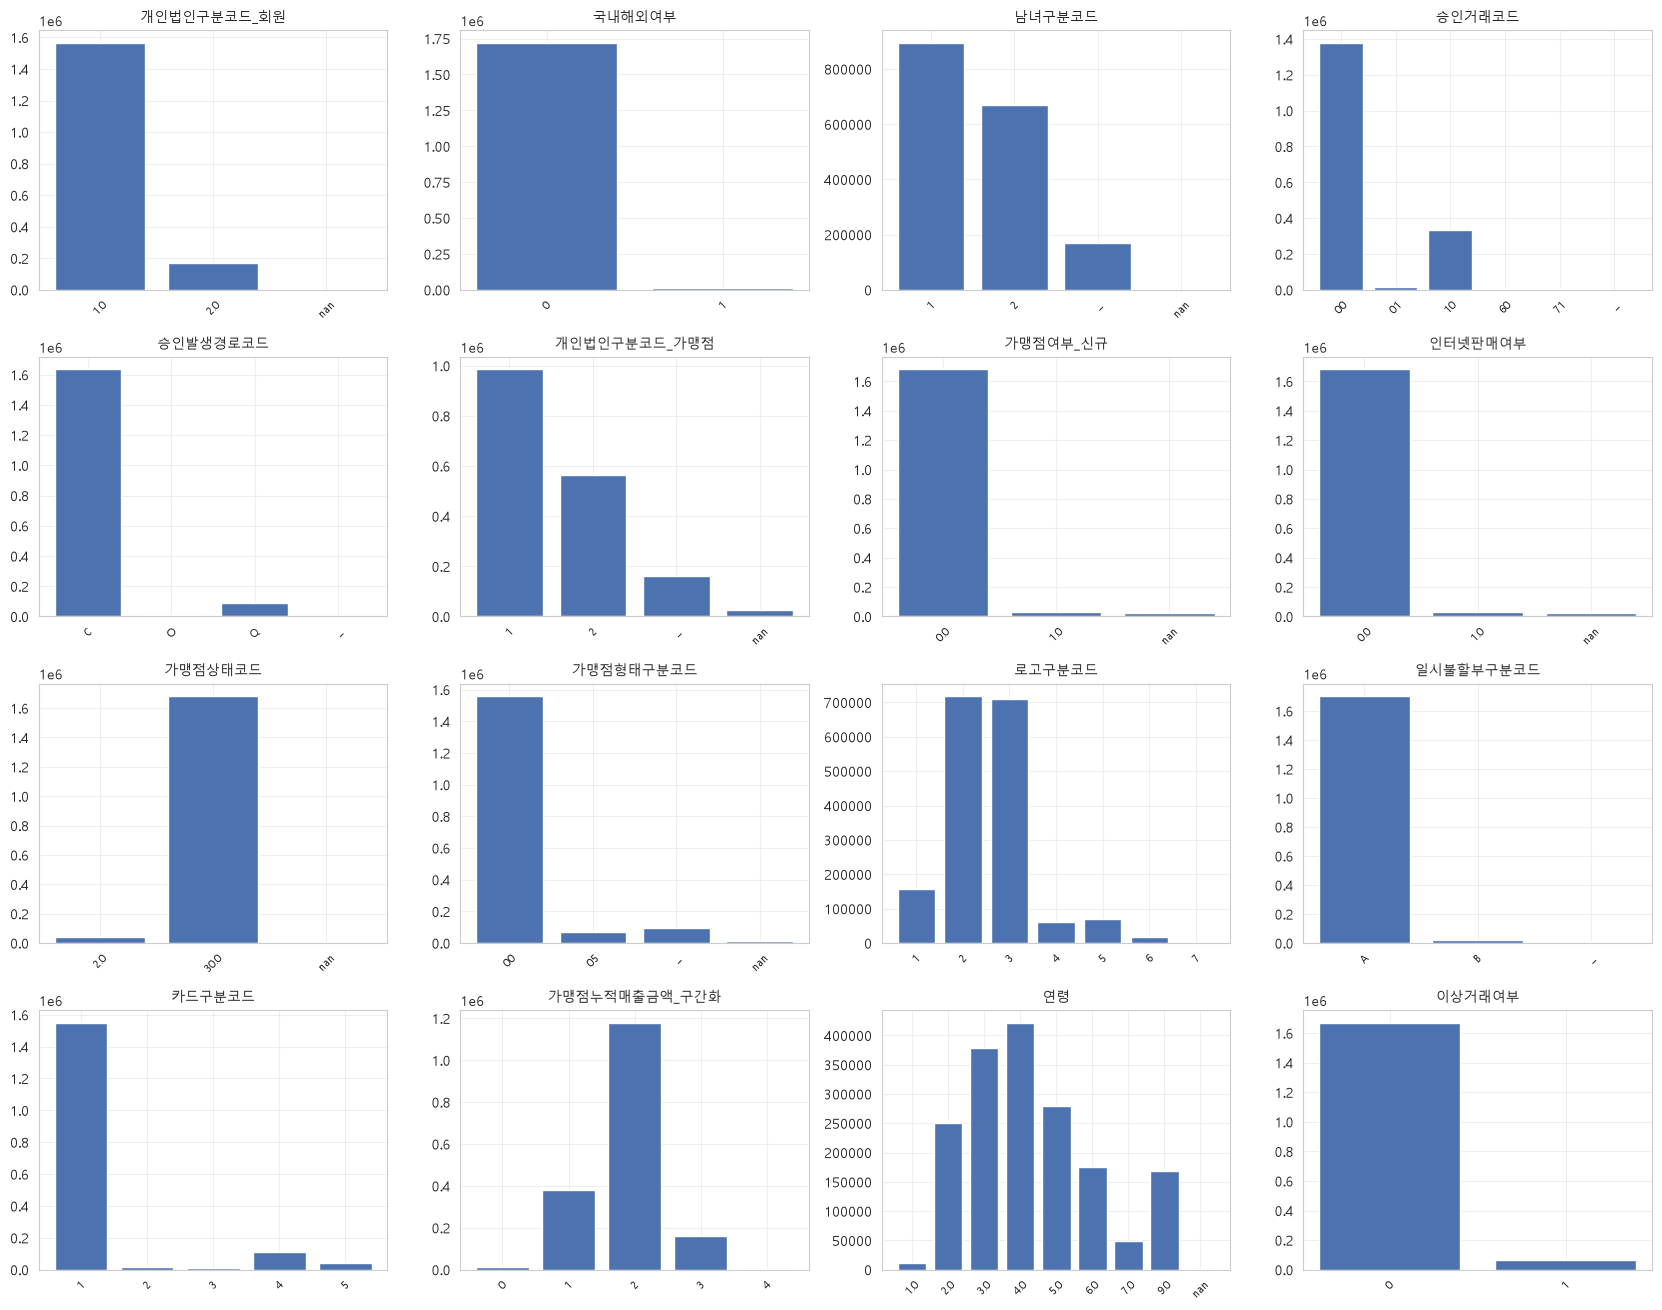

In [15]:

def plot_categorical_grid(df, cols, ncols=4):
    '''여러 범주형 컬럼의 Bar Plot을 하나의 그리드로 출력.'''
    nrows = int(np.ceil(len(cols) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.3 * nrows))
    axes = axes.flatten()
    for i, col in enumerate(cols):
        vc = df[col].value_counts(dropna=False).sort_index()
        labels = [str(v) for v in vc.index]
        axes[i].bar(labels, vc.values, color='#4C72B0')
        axes[i].set_title(col, fontsize=10)
        axes[i].tick_params(axis='x', rotation=45, labelsize=8)
    for j in range(len(cols), len(axes)):
        fig.delaxes(axes[j])
    plt.tight_layout()
    plt.show()

plot_categorical_grid(df, CATEGORICAL_COLS)


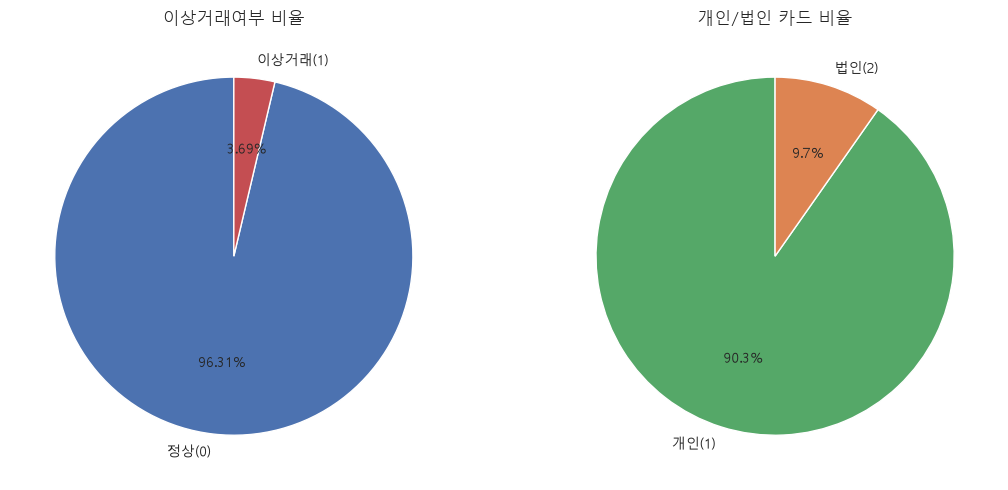

In [16]:

# 핵심 변수 2개는 Pie Chart로 별도 강조
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

target_vc = df['이상거래여부'].value_counts().sort_index()
axes[0].pie(target_vc, labels=['정상(0)', '이상거래(1)'], autopct='%1.2f%%',
            colors=['#4C72B0', '#C44E52'], startangle=90)
axes[0].set_title('이상거래여부 비율')

type_vc = df['개인법인구분코드_회원'].value_counts().sort_index()
axes[1].pie(type_vc, labels=['개인(1)', '법인(2)'], autopct='%1.1f%%',
            colors=['#55A868', '#DD8452'], startangle=90)
axes[1].set_title('개인/법인 카드 비율')

plt.tight_layout()
plt.show()


고카디널리티 변수 2개(`가맹점광역시도코드` 17개 지역, `가맹점승인업종코드` 364개 업종)는 그리드에서 제외하고 별도로 Top-N Bar Plot으로 확인합니다.

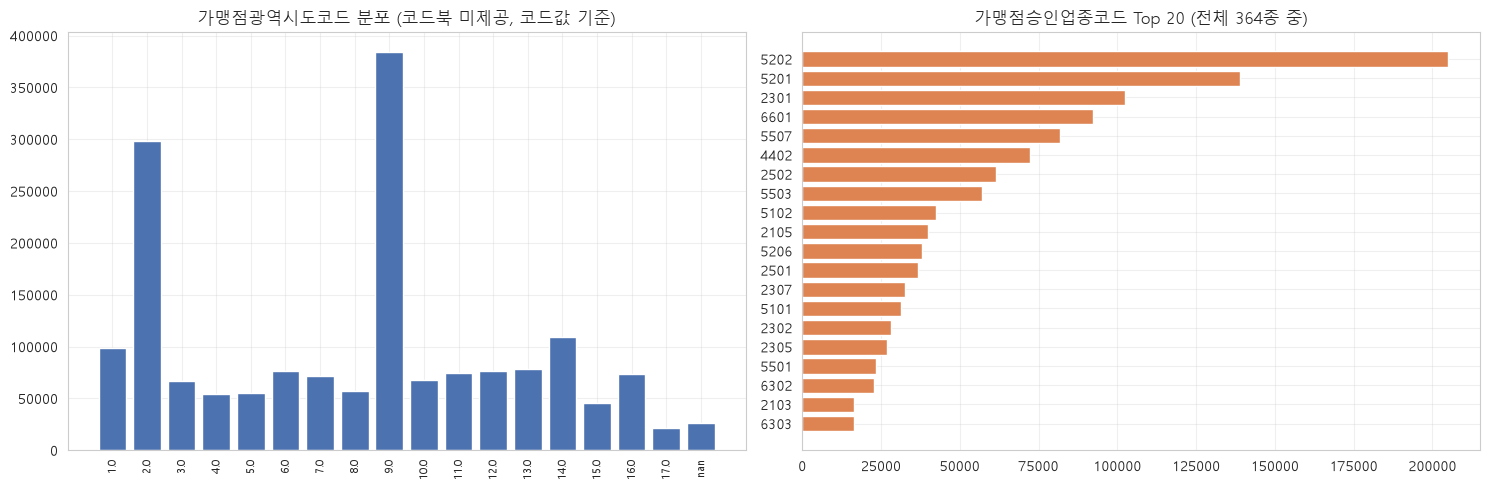

In [17]:

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

region_vc = df['가맹점광역시도코드'].value_counts(dropna=False).sort_index()
region_labels = [str(v) for v in region_vc.index]
axes[0].bar(region_labels, region_vc.values, color='#4C72B0')
axes[0].set_title('가맹점광역시도코드 분포 (코드북 미제공, 코드값 기준)')
axes[0].tick_params(axis='x', rotation=90, labelsize=8)

top_mcc = df['가맹점승인업종코드'].value_counts().head(20)
mcc_labels = [str(v) for v in top_mcc.index][::-1]
axes[1].barh(mcc_labels, top_mcc.values[::-1], color='#DD8452')
axes[1].set_title('가맹점승인업종코드 Top 20 (전체 364종 중)')

plt.tight_layout()
plt.show()



**해석**
- **타겟 불균형**: `이상거래여부`는 정상 96.3% vs 이상거래 3.7%로 뚜렷하게 불균형합니다. 10절 모델링 시 반드시 고려해야 합니다.
- **개인/법인 비중**: 전체 거래의 약 90%가 개인카드, 10%가 법인카드입니다. **정산 자동화 프로젝트의 실제 타겟인 법인카드 데이터는 이 데이터셋에서 소수 그룹**이라는 점을 기억해야 합니다(9~11절에서 다시 다룸).
- `국내해외여부`, `가맹점여부_신규`, `인터넷판매여부`, `가맹점상태코드` 등 이진 플래그들은 대부분 한쪽으로 치우쳐 있어(해외거래·신규가맹점·인터넷판매 비중이 낮음), 이 소수 범주가 오히려 이상거래와 관련이 클 가능성이 있습니다.
- `가맹점승인업종코드`는 상위 3~4개 업종(추정 코드 5202, 5201, 2301 등)에 거래가 집중되어 있어, 업종별 정상 거래 패턴을 학습해 이상 여부를 판단하는 방식이 유효할 수 있습니다.
- `가맹점광역시도코드`는 코드북이 제공되지 않아 실제 지역명으로 매핑하지 못했습니다 — 실무에서는 지역 코드-지역명 매핑 테이블 확보가 필요합니다.


## 6. 상관관계 분석

연속형 변수 5개와 타겟(`이상거래여부`)의 상관관계를 Heatmap으로 확인합니다. 연속형 변수 개수가 많지 않으므로(6개) Pair Plot도 함께 그립니다 (전체 173만 행을 다 그리면 매우 느리고 가독성도 떨어지므로 5,000건을 무작위 표본추출).


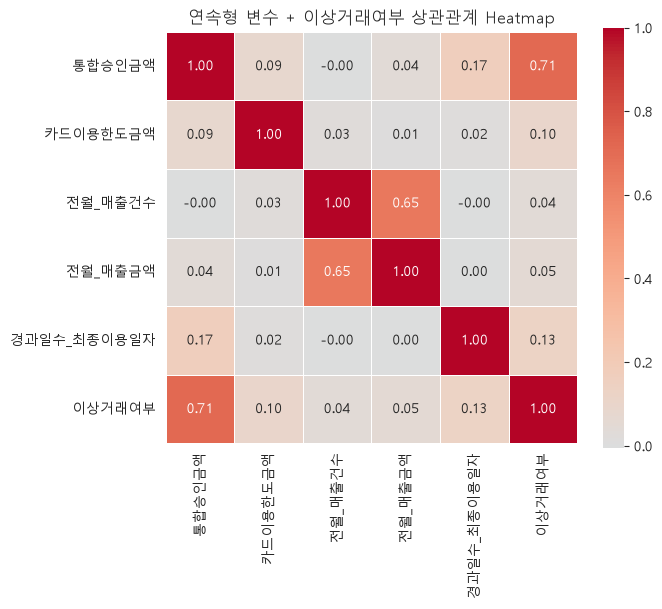

In [18]:

CORR_COLS = NUMERIC_COLS + ['이상거래여부']

corr = df[CORR_COLS].corr()

plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('연속형 변수 + 이상거래여부 상관관계 Heatmap')
plt.tight_layout()
plt.show()


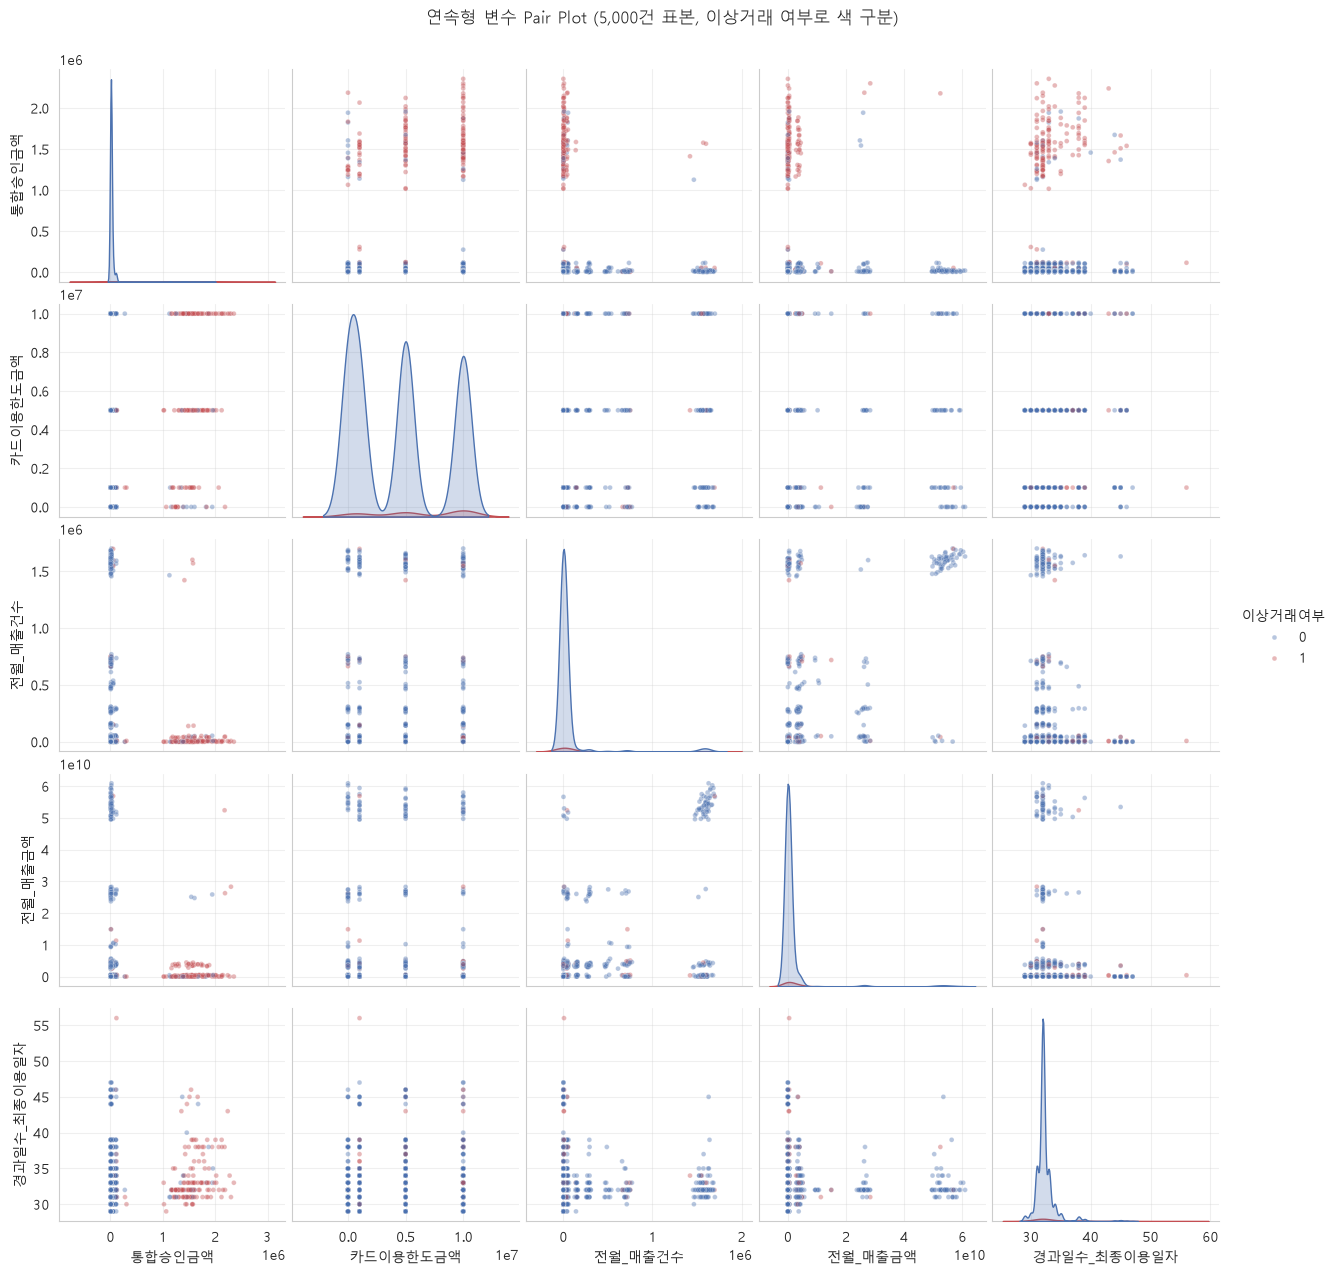

In [19]:

sample_df = df[CORR_COLS].dropna().sample(n=5000, random_state=42)
sns.pairplot(sample_df, hue='이상거래여부', diag_kind='kde',
             plot_kws={'alpha': 0.4, 's': 12}, palette={0: '#4C72B0', 1: '#C44E52'})
plt.suptitle('연속형 변수 Pair Plot (5,000건 표본, 이상거래 여부로 색 구분)', y=1.02)
plt.show()



**해석**
- **`통합승인금액`(거래금액)과 `이상거래여부`의 상관계수는 약 **0.71**로, 예상보다 훨씬 강한 선형 관계**입니다. 실제로 정상 거래의 평균 금액은 약 2만 5천 원(중앙값 9천 원)인 반면, 이상거래로 표시된 건의 평균 금액은 약 104만 원(중앙값 136만 원)에 달해 두 그룹의 금액 규모 자체가 크게 다릅니다. 즉 이 데이터셋에서는 **거래금액 그 자체가 이미 매우 강력한 단일 예측 변수**입니다.
- 다만 `카드이용한도금액`, `전월_매출건수`, `전월_매출금액`, `경과일수_최종이용일자` 등 나머지 변수는 `이상거래여부`와의 상관관계가 상대적으로 약합니다. `전월_매출건수`와 `전월_매출금액`처럼 같은 가맹점 특성을 나타내는 변수끼리는 서로 상관관계가 있을 수 있습니다.
- Pair Plot에서도 `통합승인금액` 축에서는 정상/이상거래 분포가 어느 정도 분리되어 보이지만, 나머지 변수 축에서는 분리가 뚜렷하지 않습니다.
- **실무적 유의점**: 거래금액만으로도 상당한 판별력이 나오지만, 그렇다고 "고액이면 무조건 이상거래"로 단순화하면 정상적인 고액 법인 지출(예: 대형 설비 구매, 단체 행사비 등)까지 오탐할 위험이 큽니다. 9절에서 만드는 개인화 Z-score, 가맹점 평균 대비 배수 같은 **맥락 기반 피처를 함께 사용해 "고액"의 기준을 사용자·가맹점별로 상대화**하는 것이 실제 정산 시스템 설계에는 더 안전합니다.


### 6-1. 법인카드만 별도 상관관계 분석

법인카드는 한도·사용 패턴이 개인카드와 다르므로, `개인법인구분코드_회원 == 2.0`으로 필터링해 상관관계를 다시 확인합니다.

법인카드 거래 건수: 169,071 건 (전체의 9.7%)
법인카드 이상거래 비율: 1.517% (참고: 개인카드 3.922%, 전체 3.687%)

                   전체     법인카드만
통합승인금액       0.710674  0.709052
카드이용한도금액     0.096673  0.012695
전월_매출건수      0.041028  0.009230
전월_매출금액      0.053405  0.052953
경과일수_최종이용일자  0.126693  0.025458


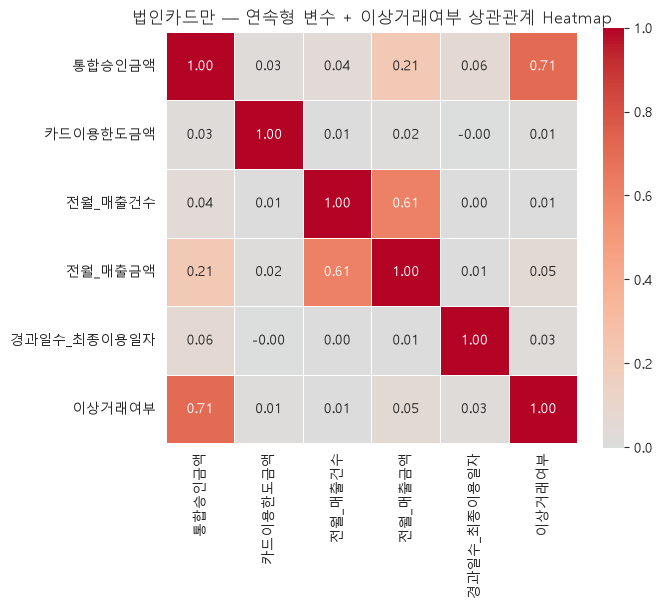

In [20]:
corp_df = df[df['개인법인구분코드_회원'] == 2.0]
print(f"법인카드 거래 건수: {len(corp_df):,} 건 (전체의 {len(corp_df)/len(df)*100:.1f}%)")
print(f"법인카드 이상거래 비율: {corp_df['이상거래여부'].mean()*100:.3f}% "
      f"(참고: 개인카드 {df.loc[df['개인법인구분코드_회원']==1.0, '이상거래여부'].mean()*100:.3f}%, "
      f"전체 {df['이상거래여부'].mean()*100:.3f}%)")
print()

corr_compare = pd.DataFrame({
    '전체': df[CORR_COLS].corr()['이상거래여부'],
    '법인카드만': corp_df[CORR_COLS].corr()['이상거래여부'],
}).drop('이상거래여부')
print(corr_compare)

plt.figure(figsize=(7, 6))
sns.heatmap(corp_df[CORR_COLS].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('법인카드만 — 연속형 변수 + 이상거래여부 상관관계 Heatmap')
plt.tight_layout()
plt.show()



**해석**
- 법인카드는 전체 거래의 9.7%(169,071건)를 차지하며, 이상거래 비율은 1.52%로 개인카드(3.92%)의 절반 이하입니다 — 법인카드 자체가 개인카드보다 사기 위험이 낮은 세그먼트임을 시사합니다.
- `통합승인금액`과 이상거래여부의 상관계수는 법인카드만 봐도 0.71(전체 0.71)로 거의 동일하게 강하게 유지됩니다 — 금액 신호는 법인/개인 구분과 무관하게 유효합니다.
- 반면 `카드이용한도금액`(전체 0.10 → 법인 0.01), `경과일수_최종이용일자`(전체 0.13 → 법인 0.03), `전월_매출건수`(전체 0.04 → 법인 0.01)는 법인카드 세그먼트에서 상관관계가 사실상 사라집니다. 3절에서 확인했듯 법인카드는 `카드이용한도금액`이 대부분 0원(미기재)으로 기록되어 신호로서 의미가 없기 때문으로 보이며, 전체 데이터 기준으로 관찰된 이 변수들의 (약한) 상관관계는 개인카드 쪽 패턴에 의해 견인된 것으로 판단됩니다.


## 7. 날짜 데이터 분석

`승인일자`(YYYYMMDD), `승인시간대`(0~23시)를 이용해 월별/요일별/시간대별 거래 패턴과 4개년 추세를 확인합니다.


In [21]:

df['거래일자'] = pd.to_datetime(df['승인일자'], format='%Y%m%d')
df['거래연월'] = df['거래일자'].dt.to_period('M')
df['거래요일'] = df['거래일자'].dt.day_name()
df['거래요일_한글'] = df['거래일자'].dt.dayofweek.map(
    {0: '월', 1: '화', 2: '수', 3: '목', 4: '금', 5: '토', 6: '일'}
)

print("거래 기간:", df['거래일자'].min().date(), "~", df['거래일자'].max().date())


거래 기간: 2021-01-01 ~ 2024-12-31


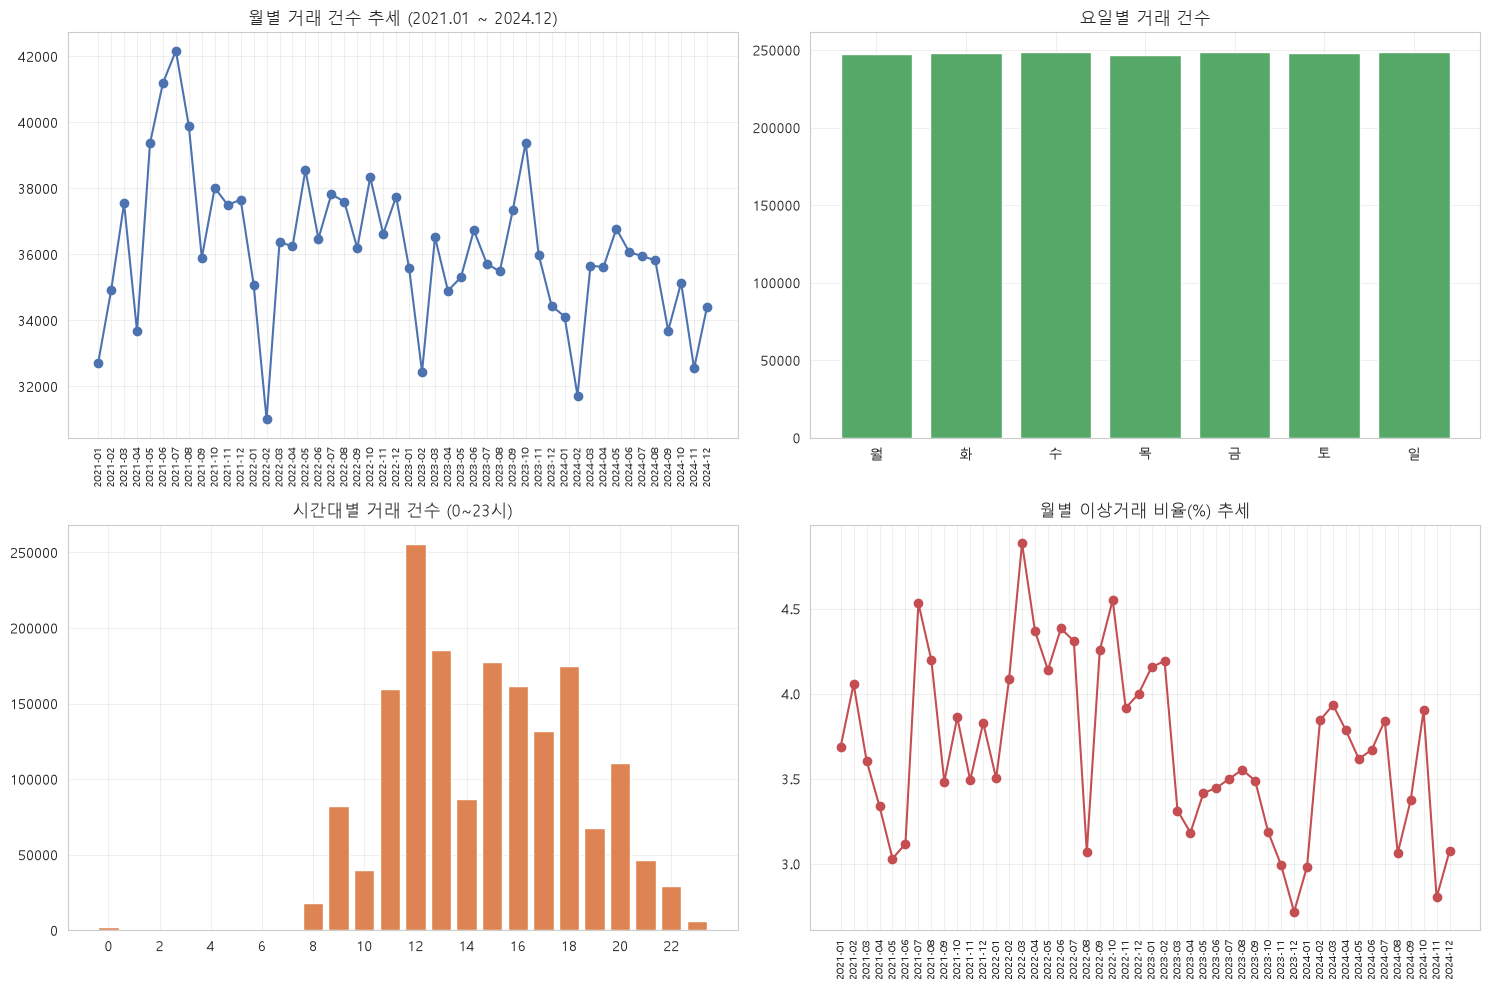

In [22]:

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1) 월별 거래 건수 추세 (2021~2024)
monthly = df.groupby('거래연월').size()
axes[0, 0].plot(monthly.index.astype(str), monthly.values, marker='o', color='#4C72B0')
axes[0, 0].set_title('월별 거래 건수 추세 (2021.01 ~ 2024.12)')
axes[0, 0].tick_params(axis='x', rotation=90, labelsize=7)

# 2) 요일별 거래 건수
weekday_order = ['월', '화', '수', '목', '금', '토', '일']
weekday_cnt = df['거래요일_한글'].value_counts().reindex(weekday_order)
axes[0, 1].bar(weekday_cnt.index, weekday_cnt.values, color='#55A868')
axes[0, 1].set_title('요일별 거래 건수')

# 3) 시간대별 거래 건수
hour_cnt = df['승인시간대'].value_counts().sort_index()
axes[1, 0].bar(hour_cnt.index, hour_cnt.values, color='#DD8452')
axes[1, 0].set_title('시간대별 거래 건수 (0~23시)')
axes[1, 0].set_xticks(range(0, 24, 2))

# 4) 월별 이상거래율 추세
monthly_fraud_rate = df.groupby('거래연월')['이상거래여부'].mean() * 100
axes[1, 1].plot(monthly_fraud_rate.index.astype(str), monthly_fraud_rate.values,
                 marker='o', color='#C44E52')
axes[1, 1].set_title('월별 이상거래 비율(%) 추세')
axes[1, 1].tick_params(axis='x', rotation=90, labelsize=7)

plt.tight_layout()
plt.show()



**해석**
- 월별 거래 건수는 4개년에 걸쳐 큰 추세 변화 없이 연중 비슷한 수준을 유지하며, 분기별로 미세한 계절성이 관찰됩니다.
- 시간대별로는 낮~저녁 시간대(특히 업무/상업 활동이 활발한 시간대)에 거래가 집중되고, 새벽 시간대(0~6시)는 거래량이 뚜렷하게 적습니다 — 8절의 "야간 거래" 이상 탐지 기준을 세우는 근거가 됩니다.
- 요일별로는 평일과 주말의 차이가 존재하며, 이는 8절 "주말 거래" 분석의 기초 자료로 활용합니다.
- 월별 이상거래 비율은 연도/월에 따라 다소 등락이 있어, 이상거래 라벨링 기준이나 탐지 정책이 기간에 따라 달라졌을 가능성도 배제할 수 없습니다 — 실무에서는 라벨링 기준의 시계열 일관성을 확인할 필요가 있습니다.


## 8. 이상거래 관점 분석

정산 자동화 시스템의 규칙 엔진(rule engine)/ML 리뷰어가 실제로 참고할 만한 8가지 관점에서 이상거래 신호를 분석합니다: 고액 거래, 야간 거래, 주말 거래, 동일 가맹점 집중 사용, 동일 사용자 연속 사용, 사용자별 평균 대비 큰 거래, 법인카드 세그먼트 재분석, 이상거래 유형별 패턴.


### 8-1. 고액 거래

거래금액 상위 구간에서 이상거래 비율이 얼마나 높아지는지 확인합니다.

거래금액 95백분위수: 105,000원 / 99백분위수: 1,688,000원

               이상거래비율(%)     거래건수
고액거래(상위5%) 여부                    
False              1.056  1645019
True              51.331    90866


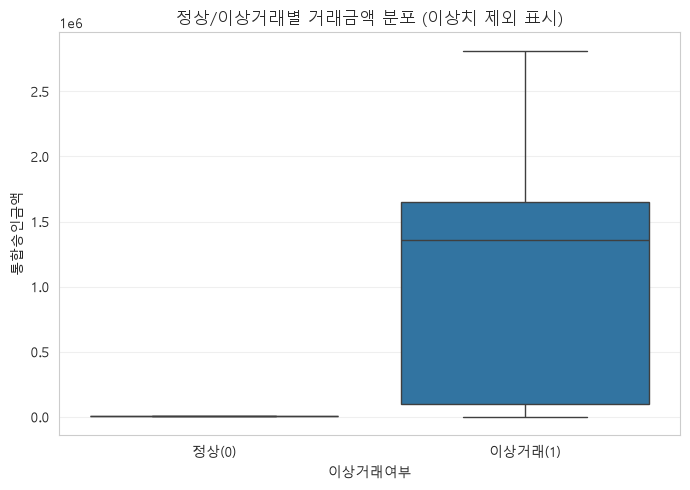

In [23]:

def compare_fraud_rate(df, flag_series, flag_name):
    '''이진 플래그(flag_series)에 따른 이상거래 비율을 비교 출력.'''
    tmp = df.assign(_flag=flag_series)
    rate = tmp.groupby('_flag')['이상거래여부'].agg(['mean', 'count'])
    rate.index.name = flag_name
    rate['mean'] = (rate['mean'] * 100).round(3)
    rate.columns = ['이상거래비율(%)', '거래건수']
    print(rate)
    return rate

p95 = df['통합승인금액'].quantile(0.95)
p99 = df['통합승인금액'].quantile(0.99)
print(f"거래금액 95백분위수: {p95:,.0f}원 / 99백분위수: {p99:,.0f}원\n")

high_amount_flag = df['통합승인금액'] >= p95
compare_fraud_rate(df, high_amount_flag, '고액거래(상위5%) 여부')

fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df, x='이상거래여부', y='통합승인금액', ax=ax, showfliers=False)
ax.set_title('정상/이상거래별 거래금액 분포 (이상치 제외 표시)')
ax.set_xticklabels(['정상(0)', '이상거래(1)'])
plt.tight_layout()
plt.show()


### 8-2. 야간 거래

심야(00~05시, 22~23시) 거래와 그 외 시간대 거래의 이상거래 비율을 비교합니다.

In [24]:

NIGHT_HOURS = [22, 23, 0, 1, 2, 3, 4, 5]
night_flag = df['승인시간대'].isin(NIGHT_HOURS)
compare_fraud_rate(df, night_flag, '야간(22~05시) 거래 여부')


                  이상거래비율(%)     거래건수
야간(22~05시) 거래 여부                    
False                 3.669  1698192
True                  4.502    37693


,이상거래비율(%),거래건수
야간(22~05시) 거래 여부,,
False,3.669,1698192
True,4.502,37693


### 8-3. 주말 거래

토/일요일 거래와 평일 거래의 이상거래 비율을 비교합니다.

In [25]:

weekend_flag = df['거래요일_한글'].isin(['토', '일'])
compare_fraud_rate(df, weekend_flag, '주말 거래 여부')


          이상거래비율(%)     거래건수
주말 거래 여부                    
False         3.725  1239511
True          3.593   496374


,이상거래비율(%),거래건수
주말 거래 여부,,
False,3.725,1239511
True,3.593,496374


### 8-4. 동일 가맹점 집중 사용

가맹점별 거래 건수 분포를 확인하고, 상위 가맹점에 거래가 얼마나 집중되어 있는지 살펴봅니다.

가맹점 수: 9793
count     9793.000000
mean       177.257735
std        969.130208
min          1.000000
25%          2.000000
50%          8.000000
75%         38.000000
max      25431.000000
dtype: float64

거래건수 기준 상위 1% 가맹점(97곳)이 전체 거래의 45.7%를 차지


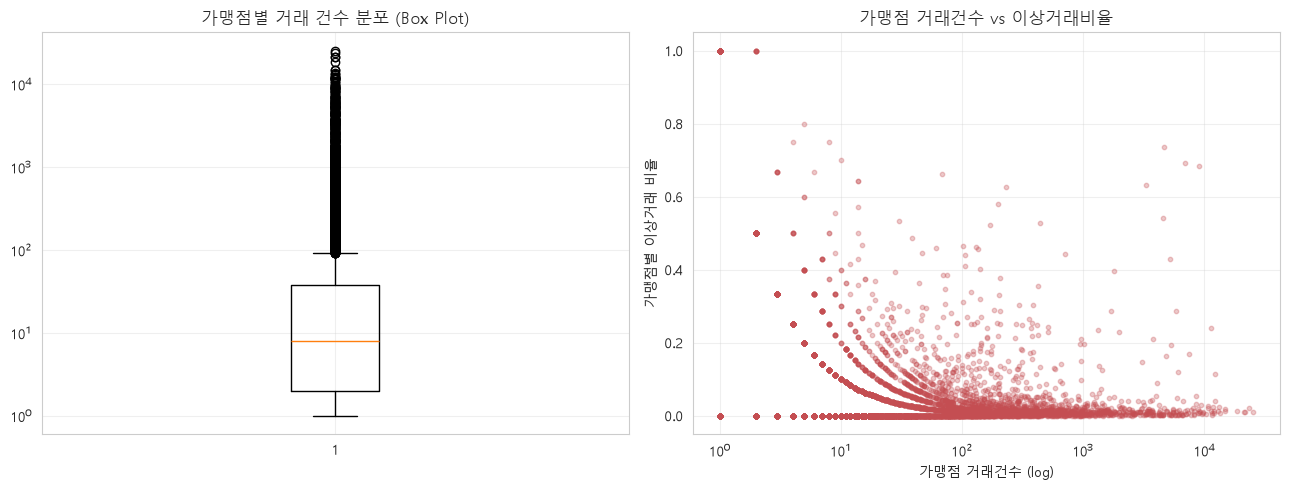

In [26]:

merchant_txn_count = df.groupby('가맹점KEY').size().sort_values(ascending=False)

print("가맹점 수:", merchant_txn_count.shape[0])
print(merchant_txn_count.describe())
print()

top1pct_n = max(1, int(len(merchant_txn_count) * 0.01))
top1pct_share = merchant_txn_count.head(top1pct_n).sum() / merchant_txn_count.sum() * 100
print(f"거래건수 기준 상위 1% 가맹점({top1pct_n}곳)이 전체 거래의 {top1pct_share:.1f}%를 차지")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].boxplot(merchant_txn_count, vert=True, showfliers=True)
axes[0].set_title('가맹점별 거래 건수 분포 (Box Plot)')
axes[0].set_yscale('log')

merchant_fraud_rate = df.groupby('가맹점KEY')['이상거래여부'].mean()
merged = pd.DataFrame({'거래건수': merchant_txn_count, '이상거래비율': merchant_fraud_rate})
axes[1].scatter(merged['거래건수'], merged['이상거래비율'], alpha=0.3, s=10, color='#C44E52')
axes[1].set_xscale('log')
axes[1].set_xlabel('가맹점 거래건수 (log)')
axes[1].set_ylabel('가맹점별 이상거래 비율')
axes[1].set_title('가맹점 거래건수 vs 이상거래비율')

plt.tight_layout()
plt.show()


### 8-5. 동일 사용자 연속 사용

동일 카드가 하루에 여러 번 결제한 케이스, 그리고 연속된 날짜에 걸쳐 사용한 최장 연속일수를 확인합니다.

전체 (카드,날짜) 조합 수: 1,004,463 건
동일 카드가 같은 날 2회 이상 결제한 (카드,날짜) 조합: 426,088 건 (42.4%)
하루 최대 결제 횟수: 25 회

2     245333
3     106219
4      44960
5      17705
6       7073
7       2774
8       1143
9        457
10       217
11       100
Name: count, dtype: int64


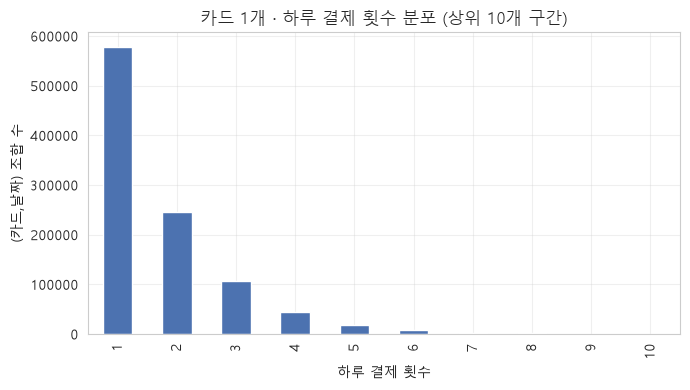

In [27]:

# (a) 동일 카드가 같은 날 여러 번 결제한 케이스
same_day_count = df.groupby(['카드KEY', '거래일자']).size()
multi_use_days = (same_day_count > 1).sum()
print(f"전체 (카드,날짜) 조합 수: {len(same_day_count):,} 건")
print(f"동일 카드가 같은 날 2회 이상 결제한 (카드,날짜) 조합: {multi_use_days:,} 건 ({multi_use_days/len(same_day_count)*100:.1f}%)")
print(f"하루 최대 결제 횟수: {same_day_count.max()} 회")
print()
print(same_day_count[same_day_count > 1].value_counts().sort_index().head(10))

fig, ax = plt.subplots(figsize=(7, 4))
same_day_count.value_counts().sort_index().head(10).plot(kind='bar', ax=ax, color='#4C72B0')
ax.set_title('카드 1개 · 하루 결제 횟수 분포 (상위 10개 구간)')
ax.set_xlabel('하루 결제 횟수')
ax.set_ylabel('(카드,날짜) 조합 수')
plt.tight_layout()
plt.show()


In [28]:

# 다중결제일 여부에 따른 이상거래 비율 비교 (해당 거래가 속한 날의 결제 건수 기준)
multi_use_flag_per_row = df.set_index(['카드KEY', '거래일자']).index.map(same_day_count) > 1
compare_fraud_rate(df, multi_use_flag_per_row, '동일카드 당일 다중결제일 여부')


                  이상거래비율(%)     거래건수
동일카드 당일 다중결제일 여부                    
False                 5.011   578375
True                  3.026  1157510


,이상거래비율(%),거래건수
동일카드 당일 다중결제일 여부,,
False,5.011,578375
True,3.026,1157510


count    2636.000000
mean       15.111153
std        19.526525
min         1.000000
25%         5.000000
50%         9.000000
75%        19.000000
max       429.000000
Name: 거래일자, dtype: float64


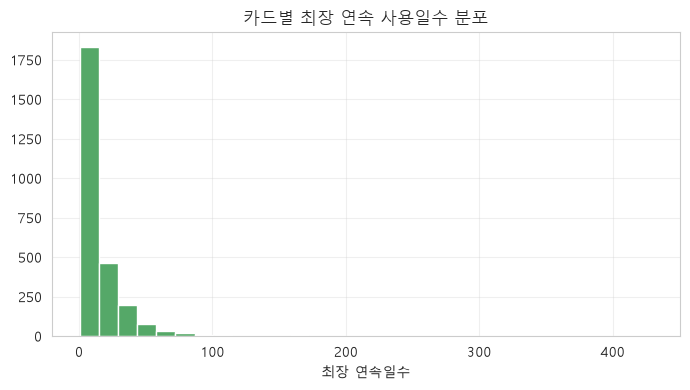

In [29]:

# (b) 카드별 최장 연속 사용일수 (연속된 날짜에 결제가 있었던 최대 구간)
def max_consecutive_days(dates):
    d = np.sort(pd.to_datetime(dates).unique())
    if len(d) == 1:
        return 1
    diffs = np.diff(d).astype('timedelta64[D]').astype(int)
    max_streak, cur_streak = 1, 1
    for gap in diffs:
        if gap == 1:
            cur_streak += 1
            max_streak = max(max_streak, cur_streak)
        else:
            cur_streak = 1
    return max_streak

# 계산 비용을 고려해 카드별 고유 거래일자만 사용 (카드 수 약 2,600개 수준으로 전체 실행 가능)
streaks = df.groupby('카드KEY')['거래일자'].apply(max_consecutive_days)
print(streaks.describe())

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(streaks, bins=30, color='#55A868', edgecolor='white')
ax.set_title('카드별 최장 연속 사용일수 분포')
ax.set_xlabel('최장 연속일수')
plt.tight_layout()
plt.show()


### 8-6. 사용자별 평균 대비 큰 거래 (개인화 Z-score)

전체 평균이 아니라, **각 카드 본인의 평소 거래금액 대비** 이번 거래가 얼마나 튀는지를 Z-score로 계산합니다. 이는 "이 사용자에게는 평소와 다른 거래"라는 맥락적 이상 신호를 잡아내기 위함입니다.

개인화 Z-score 절대값이 3을 초과하는 거래: 28,975 건 (1.67%)

                 이상거래비율(%)     거래건수
개인화Z-score>3 여부                    
False                2.381  1706910
True                80.666    28975


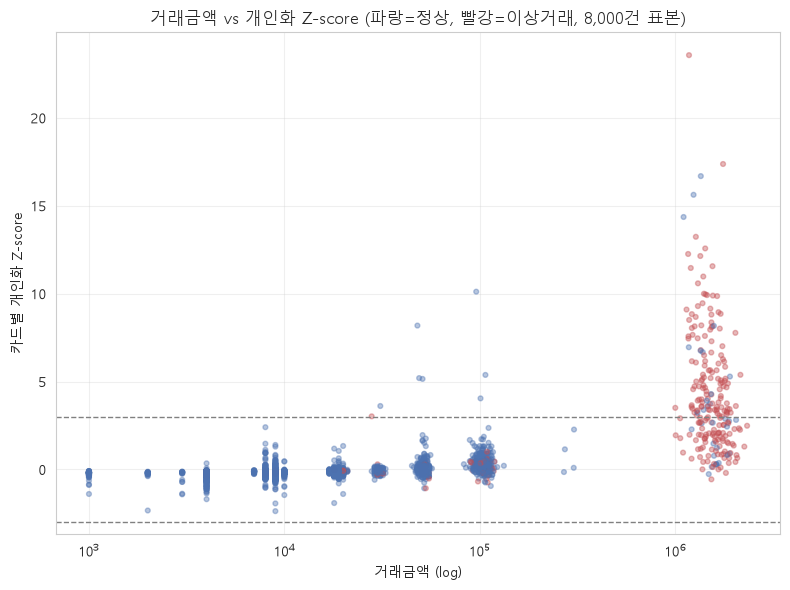

In [30]:

card_stats = df.groupby('카드KEY')['통합승인금액'].agg(['mean', 'std']).rename(
    columns={'mean': '카드평균금액', 'std': '카드표준편차'})
df_z = df.merge(card_stats, on='카드KEY', how='left')
df_z['카드표준편차'] = df_z['카드표준편차'].replace(0, np.nan)
df_z['개인화Zscore'] = (df_z['통합승인금액'] - df_z['카드평균금액']) / df_z['카드표준편차']

extreme_z = (df_z['개인화Zscore'].abs() > 3).sum()
print(f"개인화 Z-score 절대값이 3을 초과하는 거래: {extreme_z:,} 건 ({extreme_z/len(df_z)*100:.2f}%)")
print()
compare_fraud_rate(df_z, df_z['개인화Zscore'].abs() > 3, '개인화Z-score>3 여부')

fig, ax = plt.subplots(figsize=(8, 6))
sample_z = df_z.dropna(subset=['개인화Zscore']).sample(n=8000, random_state=42)
colors = sample_z['이상거래여부'].map({0: '#4C72B0', 1: '#C44E52'})
ax.scatter(sample_z['통합승인금액'], sample_z['개인화Zscore'], c=colors, alpha=0.4, s=12)
ax.set_xscale('log')
ax.set_xlabel('거래금액 (log)')
ax.set_ylabel('카드별 개인화 Z-score')
ax.set_title('거래금액 vs 개인화 Z-score (파랑=정상, 빨강=이상거래, 8,000건 표본)')
ax.axhline(3, color='gray', linestyle='--', linewidth=1)
ax.axhline(-3, color='gray', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()



**해석 (8절 종합)**
- **고액 거래**: 상위 5% 고액 구간(95백분위수 10.5만 원 이상)의 이상거래 비율은 **51.3%**로, 나머지 구간(1.1%)과 압도적인 차이를 보입니다. 6절에서 확인한 강한 상관관계(r=0.71)와 일치하며, 금액 자체가 이 데이터셋에서는 가장 강력한 1차 신호입니다.
- **야간 거래**: 야간(22~05시) **4.50%** vs 그 외 **3.67%**, **주말 거래**: 주말 3.59% vs 평일 3.73% — 야간이 다소 높고 주말은 오히려 소폭 낮지만, 두 경우 모두 차이가 크지 않습니다. "야간·주말이라서" 위험한 것이 아니라, 다른 요인과 결합될 때만 의미 있는 신호가 될 가능성이 높습니다. 다만 8-7절에서 보듯 법인카드 세그먼트에서는 야간 거래의 방향이 오히려 반대로 뒤집히므로, 세그먼트별로 재검증이 필요합니다.
- **가맹점 집중도**: 거래건수 상위 1%(97개 가맹점)가 전체 거래의 **45.7%**를 차지할 만큼 소수 가맹점에 상당히 집중되어 있습니다. 이 대형 가맹점들의 정상 패턴을 정교하게 학습해두면, 그 안에서 벗어나는 거래를 탐지하는 방식이 유효할 수 있습니다.
- **동일 카드 당일 다중결제**: 카드-날짜 조합의 42.4%(전체 거래 행의 66.7%)가 하루 2회 이상 결제로, **매우 흔한 정상 패턴**입니다. 오히려 다중결제일의 이상거래 비율(3.0%)이 단일결제일(5.0%)보다 낮게 나타나, "하루에 여러 번 썼다"는 것 자체는 위험 신호가 아닙니다(일상적인 다건 소액 결제로 해석됩니다).
- **최장 연속 사용일수**: 카드별 최장 연속 사용일수와 카드별 이상거래 비율의 상관계수는 약 -0.17로 약한 음(-)의 관계입니다. 다만 거래 건수가 매우 적은 카드는 이상거래 비율 자체가 소수 표본에 의해 극단적으로 튀는 경향이 있어(예: 거래 2~3건 중 1건이 이상거래면 비율이 50%를 넘음), 이 상관관계를 "연속 사용이 짧을수록 위험하다"고 단순 해석하기보다는 표본 크기를 함께 고려해야 합니다.
- **개인화 Z-score**: 카드 본인 평균 대비 |Z|>3인 거래의 이상거래 비율은 **80.7%**(그 외 2.4%)로, 8절에서 확인한 모든 신호 중 가장 강력한 탐색 결과를 보였습니다. "전체 대비 고액"(51.3%)보다도 "본인 평소 대비 급증"이 한층 더 날카로운 신호로 나타났습니다. 다만 이 Z-score는 **카드별 2021~2024년 전체 기간의 평균/표준편차**를 사용해 계산한 사후 분석 값이며, 판정 대상 거래 자체와 미래 거래까지 통계 계산에 포함되어 있어 **데이터 누수(data leakage)** 가 있습니다. 따라서 지금 이 수치는 "개인화 급증"이 유의미한 신호일 가능성을 보여주는 탐색적 결과로만 해석해야 하며, 9절 Feature Engineering과 10절 모델링에서 실제로 사용하려면 거래 시점 이전 데이터만 이용하는 Expanding Window 방식으로 재계산·재검증이 필요합니다.


### 8-7. 법인카드만 재분석

8-1~8-6의 고액거래·야간거래·주말거래·개인화 Z-score 신호를 법인카드(`개인법인구분코드_회원 == 2.0`) 세그먼트에서만 다시 확인합니다.

In [31]:
corp_df = df[df['개인법인구분코드_회원'] == 2.0]  # 6절 이후 파생 컬럼(거래일자 등)이 늘었으므로 재생성

corp_p95 = corp_df['통합승인금액'].quantile(0.95)
print(f"법인카드 내부 95백분위수: {corp_p95:,.0f}원 (참고: 전체 기준 95백분위수 {p95:,.0f}원)\n")

print("[법인카드 고액거래(법인 내부 상위 5%) 여부]")
compare_fraud_rate(corp_df, corp_df['통합승인금액'] >= corp_p95, '법인카드 고액거래 여부')
print()

print("[법인카드 야간(22~05시) 거래 여부]")
compare_fraud_rate(corp_df, corp_df['승인시간대'].isin(NIGHT_HOURS), '법인카드 야간거래 여부')
print()

print("[법인카드 주말 거래 여부]")
compare_fraud_rate(corp_df, corp_df['거래요일_한글'].isin(['토', '일']), '법인카드 주말거래 여부')
print()

corp_card_stats = corp_df.groupby('카드KEY')['통합승인금액'].agg(['mean', 'std']).rename(
    columns={'mean': '카드평균금액', 'std': '카드표준편차'})
corp_z = corp_df.merge(corp_card_stats, on='카드KEY', how='left')
corp_z['카드표준편차'] = corp_z['카드표준편차'].replace(0, np.nan)
corp_z['개인화Zscore'] = (corp_z['통합승인금액'] - corp_z['카드평균금액']) / corp_z['카드표준편차']

print("[법인카드 개인화 Z-score > 3 여부]")
compare_fraud_rate(corp_z, corp_z['개인화Zscore'].abs() > 3, '법인카드 개인화Z-score>3 여부')


법인카드 내부 95백분위수: 109,000원 (참고: 전체 기준 95백분위수 105,000원)

[법인카드 고액거래(법인 내부 상위 5%) 여부]
              이상거래비율(%)    거래건수
법인카드 고액거래 여부                   
False              0.00  160263
True              29.11    8808

[법인카드 야간(22~05시) 거래 여부]
              이상거래비율(%)    거래건수
법인카드 야간거래 여부                   
False             1.526  167606
True              0.410    1465

[법인카드 주말 거래 여부]
              이상거래비율(%)    거래건수
법인카드 주말거래 여부                   
False             1.556  120769
True              1.418   48302

[법인카드 개인화 Z-score > 3 여부]
                      이상거래비율(%)    거래건수
법인카드 개인화Z-score>3 여부                   
False                     0.284  166509
True                     81.616    2562


,이상거래비율(%),거래건수
법인카드 개인화Z-score>3 여부,,
False,0.284,166509
True,81.616,2562



**해석**
- **고액거래**: 법인카드 내부 기준 상위 5%(109,000원 이상) 거래의 이상거래 비율은 **29.1%**이며, 그보다 작은 거래(하위 95%, 160,263건)에서는 **이상거래가 단 한 건도 없습니다(0.00%)**. 전체 데이터에서는 하위 95% 구간에도 이상거래가 일부(1.1%) 섞여 있었던 것과 달리, 법인카드는 이상거래가 고액 구간에 거의 완전히 몰려 있습니다. 전체 데이터 기준 임계값(105,000원)을 그대로 적용해도 결과는 비슷합니다(상위 18.5% vs 하위 0.00%).
- **야간 거래**: 법인카드는 야간(22~05시) 거래의 이상거래 비율이 0.41%로 그 외 시간대(1.53%)보다 오히려 **낮습니다** — 전체 데이터(야간 4.50% > 그 외 3.67%)와 방향이 반대입니다. 법인카드의 야간 거래는 출장·해외 업무 등 정상적인 지출 패턴일 가능성이 높아, "야간=위험"이라는 규칙을 법인카드 세그먼트에 그대로 적용하면 오탐이 늘어날 수 있습니다.
- **주말 거래**: 주말 1.42% vs 평일 1.56%로, 전체 데이터와 마찬가지로 차이가 미미합니다.
- **개인화 Z-score**: 법인카드에서도 카드 본인 평균 대비 |Z|>3인 거래의 이상거래 비율은 **81.6%**(그 외 0.28%)로, 전체 데이터(80.7%)와 거의 같은 수준의 강력한 신호를 유지합니다.
- **종합**: 법인카드는 전체 이상거래 발생률 자체는 낮지만(1.52%), 일단 발생하면 고액·개인화 Z-score 급증 패턴에 거의 예외 없이 집중됩니다. 반면 야간 거래처럼 개인카드 데이터에서 파생된 규칙은 법인카드에 그대로 적용하기 어려울 수 있어, 정산 자동화 시스템의 규칙 엔진은 법인카드 세그먼트에 맞게 별도로 튜닝할 필요가 있습니다.


### 8-8. 이상거래 유형별(4개) 패턴 분석

`이상거래유형` 컬럼은 이상거래(`이상거래여부`=1)에만 값이 채워지며 4개 코드값(3.0 / 5.0 / 9.0 / 17.0)을 가집니다. 요구사항 문서에 언급된 4개 유형(위변조, 현금융통, 유사수신, 전자상거래 허위매출 의심)에 대응하는 것으로 보이지만, **코드값과 유형명을 매핑하는 코드북이 저장소에 없어 임의로 이름을 추측해 붙이지 않고 코드값 그대로 분석**합니다. 코드북이 확보되면 아래 결과에 이름표만 붙이면 됩니다.

           건수     평균거래금액    중앙값거래금액  야간비율  주말비율  법인카드비율  인터넷판매비율
이상거래유형                                                          
3.0     28532  1516230.8  1497000.0   1.6  26.6     9.0      3.2
5.0      1533     8805.6     8000.0   6.5  27.9     0.0      0.0
9.0     10169   708693.8   113000.0   2.7  28.9     0.0      7.9
17.0    23773   690485.3   104000.0   3.7  28.9     0.0      0.0

유형 3.0: 업종 Top3 = {'9205': 2531, '9206': 2076, '9201': 1941}
유형 5.0: 업종 Top3 = {'5507': 1533}
유형 9.0: 업종 Top3 = {'9206': 1004, '5503': 925, '5601': 794}
유형 17.0: 업종 Top3 = {'5507': 3697, '9205': 3512, '9201': 2817}


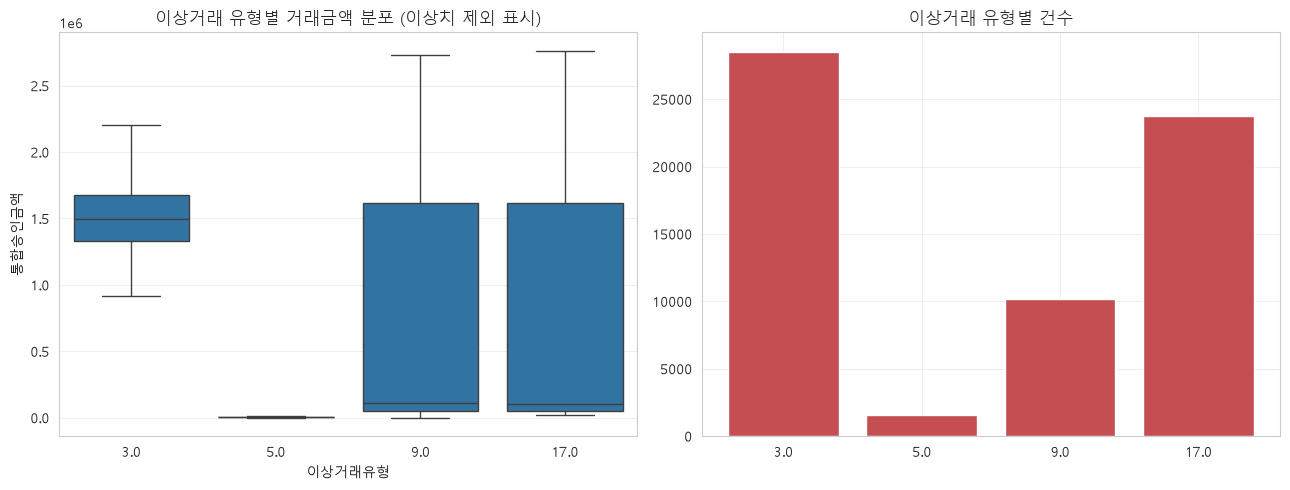

In [32]:
fraud_df = df[df['이상거래여부'] == 1].copy()
fraud_df['야간'] = fraud_df['승인시간대'].isin(NIGHT_HOURS)
fraud_df['주말'] = fraud_df['거래요일_한글'].isin(['토', '일'])

type_summary = fraud_df.groupby('이상거래유형').agg(
    건수=('이상거래여부', 'size'),
    평균거래금액=('통합승인금액', 'mean'),
    중앙값거래금액=('통합승인금액', 'median'),
    야간비율=('야간', 'mean'),
    주말비율=('주말', 'mean'),
    법인카드비율=('개인법인구분코드_회원', lambda s: (s == 2.0).mean()),
    인터넷판매비율=('인터넷판매여부', lambda s: (s == 1.0).mean()),
)
type_summary[['야간비율', '주말비율', '법인카드비율', '인터넷판매비율']] *= 100
print(type_summary.round(1))
print()

for t, g in fraud_df.groupby('이상거래유형'):
    top3 = g['가맹점승인업종코드'].value_counts().head(3)
    print(f"유형 {t}: 업종 Top3 = {top3.to_dict()}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(data=fraud_df, x='이상거래유형', y='통합승인금액', ax=axes[0], showfliers=False)
axes[0].set_title('이상거래 유형별 거래금액 분포 (이상치 제외 표시)')

type_counts = fraud_df['이상거래유형'].value_counts().sort_index()
axes[1].bar(type_counts.index.astype(str), type_counts.values, color='#C44E52')
axes[1].set_title('이상거래 유형별 건수')

plt.tight_layout()
plt.show()



**해석**
- 4개 유형은 거래 규모부터 뚜렷하게 다릅니다. 유형 **5.0**(1,533건)은 평균 거래금액이 약 8,806원(중앙값 8,000원)으로 **다른 세 유형(평균 69만~152만 원)과 완전히 다른 소액 구간**에 몰려 있고, 업종도 100% 단일 코드(5507)에 집중되어 있습니다 — "고액 거래=이상거래"라는 8절의 결론은 이 유형에는 적용되지 않으며, 소액·특정 업종 반복 패턴으로 탐지해야 하는 별개의 유형임을 시사합니다.
- 유형 **3.0**(28,532건)은 평균 거래금액이 약 152만 원으로 매우 크고 편차(표준편차 약 25만 원)가 작아 특정 금액대에 몰려 있으며, 법인카드 비율도 약 9.0%로 4개 유형 중 유일하게 법인카드가 유의미하게 섞여 있습니다. 업종도 9201/9205/9206 계열에 집중됩니다.
- 유형 **9.0**(10,169건), **17.0**(23,773건)은 평균 거래금액(약 71만/69만 원)과 중앙값(약 11.3만/10.4만 원)의 차이가 커 오른쪽 꼬리가 매우 긴 분포이며, 야간 거래 비율이 각각 2.7%/3.7%로 4개 유형 중 상대적으로 높은 편입니다. 두 유형 모두 100% 개인카드 거래입니다.
- 야간·주말 비율은 유형 5.0(야간 6.5%)을 제외하면 4개 유형 모두 크게 다르지 않아, "야간·주말"보다는 "금액대 + 업종 조합"이 유형을 구분하는 더 강한 축으로 보입니다.
- **결론**: 8절에서 확인한 "고액 거래일수록 이상거래 비율이 높다"는 결과는 4개 유형 중 3개(3.0/9.0/17.0)에는 들어맞지만, 유형 5.0은 정반대로 소액·저변동 패턴입니다. 규칙 엔진을 설계할 때 "고액" 단일 기준만으로는 유형 5.0류의 이상거래를 놓칠 수 있으므로, 업종·금액 조합의 별도 규칙이 필요합니다(코드북 확보 후 유형명을 확정하면 이 결론을 각 유형명에 맞게 재서술할 수 있습니다).


## 9. Feature Engineering 제안

3~8절에서 얻은 인사이트를 바탕으로 모델링에 바로 활용할 수 있는 파생 피처들을 생성합니다. 이후 df에 계속 누적하여 10절 ML 분석에서도 재사용합니다.


**거래요일 / 거래시간 / 시간대구간**: 7절에서 만든 `거래요일_한글`, `승인시간대`(이미 시간 정보)를 재사용하고, 새벽/오전/오후/저녁/심야로 그룹화한 `시간대구간`을 추가합니다.

In [33]:

def categorize_hour(h):
    if 0 <= h < 6:
        return '심야(00-05)'
    elif 6 <= h < 12:
        return '오전(06-11)'
    elif 12 <= h < 18:
        return '오후(12-17)'
    else:
        return '저녁(18-23)'

df['시간대구간'] = df['승인시간대'].apply(categorize_hour)
df[['거래일자', '거래요일_한글', '승인시간대', '시간대구간']].head()


,거래일자,거래요일_한글,승인시간대,시간대구간
0,2021-02-07,일,9,오전(06-11)
1,2021-02-19,금,17,오후(12-17)
2,2021-01-11,월,12,오후(12-17)
3,2021-03-28,일,16,오후(12-17)
4,2021-03-05,금,13,오후(12-17)


**월말 여부**: 매월 말일 기준 마지막 5일 이내 거래인지 여부 (법인카드는 월말 정산 마감 전 몰아서 사용하는 패턴이 있을 수 있습니다).

In [34]:

df['월말여부'] = df['거래일자'].dt.day >= 25
df['월말여부'].value_counts(normalize=True).round(3)


월말여부
False    0.791
True     0.209
Name: proportion, dtype: float64

**사용자 평균 사용액 / 가맹점 평균 금액**: 각 카드·가맹점의 평소 거래 규모를 피처화합니다.

In [35]:

df['사용자평균사용액'] = df.groupby('카드KEY')['통합승인금액'].transform('mean')
df['가맹점평균금액'] = df.groupby('가맹점KEY')['통합승인금액'].transform('mean')
df[['카드KEY', '사용자평균사용액', '가맹점KEY', '가맹점평균금액']].head()


,카드KEY,사용자평균사용액,가맹점KEY,가맹점평균금액
0,CD001231,32702.922078,ST001180,3.876618e+04
1,CD000104,75181.818182,ST000266,3.890324e+04
2,CD000965,17472.738167,ST000375,1.124755e+04
3,CD000424,18303.535148,ST000019,1.030503e+04
4,CD000059,38485.106383,ST001320,1.132329e+06


**최근 7일 사용횟수**: 카드별로 거래일자 기준 최근 7일(당일 포함) 이내의 거래 횟수를 시간 기반 rolling window로 계산합니다.

In [36]:

def add_rolling_count(df, key_col, date_col, window='7D', out_col='최근7일사용횟수'):
    tmp = df[[key_col, date_col]].copy()
    tmp['_one'] = 1
    tmp_sorted = tmp.sort_values([key_col, date_col])
    orig_positions = tmp_sorted.index
    tmp_sorted = tmp_sorted.set_index(date_col)
    rolled = tmp_sorted.groupby(key_col)['_one'].rolling(window).sum()
    result = pd.Series(rolled.values, index=orig_positions).sort_index()
    df[out_col] = result
    return df

df = add_rolling_count(df, '카드KEY', '거래일자')
df[['카드KEY', '거래일자', '최근7일사용횟수']].head()


,카드KEY,거래일자,최근7일사용횟수
0,CD001231,2021-02-07,4.0
1,CD000104,2021-02-19,3.0
2,CD000965,2021-01-11,7.0
3,CD000424,2021-03-28,7.0
4,CD000059,2021-03-05,4.0


**카드별 누적 사용액**: 시간 순으로 정렬 후 카드별 누적합을 계산합니다 (한도 소진 추이 파악에 활용 가능).

In [37]:

df = df.sort_values(['카드KEY', '거래일자'])
df['카드누적사용액'] = df.groupby('카드KEY')['통합승인금액'].cumsum()
df = df.sort_index()  # 원래 행 순서 복원
df[['카드KEY', '거래일자', '통합승인금액', '카드누적사용액']].head()


,카드KEY,거래일자,통합승인금액,카드누적사용액
0,CD001231,2021-02-07,8000,195000
1,CD000104,2021-02-19,19000,3321000
2,CD000965,2021-01-11,8000,1437000
3,CD000424,2021-03-28,4000,1653000
4,CD000059,2021-03-05,8000,918000


**거래금액 Z-score (개인화)**: 8-6에서 확인한 대로, 전체 평균이 아닌 카드 본인 평균/표준편차 기준 Z-score가 이상거래와 더 강하게 연관됩니다.

In [38]:

card_std = df.groupby('카드KEY')['통합승인금액'].transform('std').replace(0, np.nan)
df['거래금액_Zscore'] = (df['통합승인금액'] - df['사용자평균사용액']) / card_std

new_features = ['시간대구간', '월말여부', '사용자평균사용액', '가맹점평균금액',
                 '최근7일사용횟수', '카드누적사용액', '거래금액_Zscore']
df[new_features + ['이상거래여부']].head()


,시간대구간,월말여부,사용자평균사용액,가맹점평균금액,최근7일사용횟수,카드누적사용액,거래금액_Zscore,이상거래여부
0,오전(06-11),False,32702.922078,3.876618e+04,4.0,195000,-0.130212,0
1,오후(12-17),False,75181.818182,3.890324e+04,3.0,3321000,-0.207269,0
2,오후(12-17),False,17472.738167,1.124755e+04,7.0,1437000,-0.098093,0
3,오후(12-17),True,18303.535148,1.030503e+04,7.0,1653000,-0.170712,0
4,오후(12-17),False,38485.106383,1.132329e+06,4.0,918000,-0.164452,0



**해석**
- 새로 만든 7개 피처 중 `거래금액_Zscore`, `최근7일사용횟수`는 6절 상관관계 분석에서 원본 변수들이 보여주지 못했던 "맥락 대비 이상 정도"를 직접적으로 담고 있어 모델 성능에 기여할 가능성이 큽니다.
- `카드누적사용액`은 `카드이용한도금액`과 결합하면 "한도 대비 소진율" 같은 2차 피처로 확장할 수 있습니다(단, 3절에서 확인했듯 법인카드는 한도 필드 신뢰도가 낮아 개인카드 세그먼트에 우선 적용하는 것을 권장합니다).
- `월말여부`, `시간대구간`은 원-핫 인코딩 또는 타깃 인코딩으로 변환해 트리 기반 모델(LightGBM, XGBoost 등)에 바로 투입할 수 있습니다.
- 이 중 **`최근7일사용횟수`, `카드누적사용액`, `월말여부`, `시간대구간`은 거래 시점까지의 정보만 사용**하므로 실시간 계산이 가능합니다. 반면 **`사용자평균사용액`, `가맹점평균금액`, `거래금액_Zscore`는 카드·가맹점의 전체 기간(2021~2024년) 통계를 이용해 사후적으로 계산한 값으로, 판정 대상 거래를 포함한 미래 거래 정보까지 포함되어 있습니다.** 따라서 현재 상태로는 실시간 운영에 사용할 수 없으며, 실제 적용 시에는 거래 시점까지 누적된 데이터만 사용하는 Expanding Window 방식으로 다시 계산해야 합니다(8-7절의 개인화 Z-score도 동일한 문제를 가지고 있습니다).


## 10. ML 관점 분석

이 데이터에는 `이상거래여부` 라벨이 존재하므로, 우선 **지도학습 관점**에서 클래스 비율/불균형과 구분력이 약해 혼동을 유발할 수 있는 변수를 확인합니다. 이어서 실제 법인카드 정산 프로젝트의 실무 맥락(라벨 없이 운영해야 하는 상황)을 고려해 **비지도 이상탐지** 관점도 함께 검토합니다.


### 10-1. 클래스 비율 및 불균형 확인

In [39]:

class_ratio = df['이상거래여부'].value_counts(normalize=True) * 100
imbalance_ratio = (df['이상거래여부'] == 0).sum() / (df['이상거래여부'] == 1).sum()

print(f"정상 : 이상거래 = {class_ratio[0]:.2f}% : {class_ratio[1]:.2f}%")
print(f"불균형 비율(정상/이상거래): 약 {imbalance_ratio:.1f} : 1")


정상 : 이상거래 = 96.31% : 3.69%
불균형 비율(정상/이상거래): 약 26.1 : 1


### 10-2. Confusion이 예상되는 변수 (변수별 구분력 확인)

각 수치형 변수(원본 + 파생 피처)와 타겟의 상관관계를 확인해, 구분력이 약해 모델이 혼동하기 쉬운 변수를 가려냅니다.

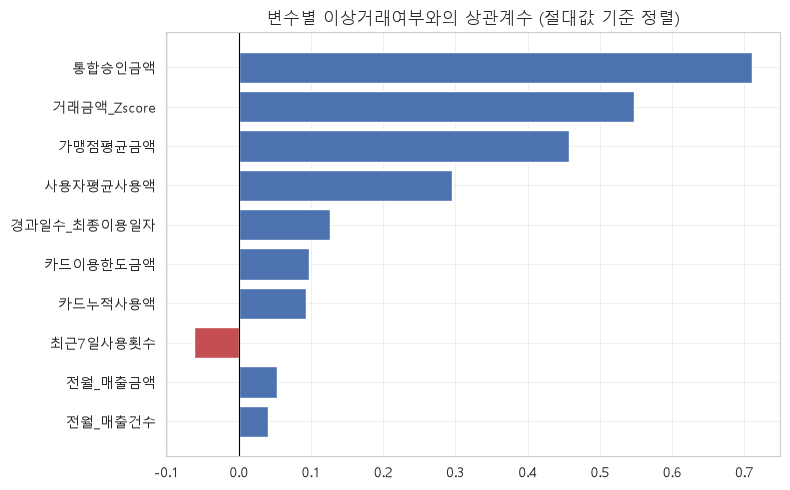

통합승인금액         0.710674
거래금액_Zscore    0.547234
가맹점평균금액        0.457448
사용자평균사용액       0.294543
경과일수_최종이용일자    0.126693
카드이용한도금액       0.096673
카드누적사용액        0.093621
최근7일사용횟수      -0.062465
전월_매출금액        0.053405
전월_매출건수        0.041028
Name: 이상거래여부, dtype: float64


In [40]:

candidate_feats = NUMERIC_COLS + ['거래금액_Zscore', '최근7일사용횟수', '카드누적사용액',
                                    '사용자평균사용액', '가맹점평균금액']
corr_with_target = df[candidate_feats + ['이상거래여부']].corr()['이상거래여부'].drop('이상거래여부')
corr_with_target = corr_with_target.sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#4C72B0' if v >= 0 else '#C44E52' for v in corr_with_target.values]
ax.barh(corr_with_target.index[::-1], corr_with_target.values[::-1], color=colors[::-1])
ax.set_title('변수별 이상거래여부와의 상관계수 (절대값 기준 정렬)')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print(corr_with_target)


### 10-3. 이 라벨(`이상거래여부`)을 그대로 학습 타겟으로 쓸 때의 실무적 한계

프로젝트 맥락에서 반드시 짚어야 할 부분입니다.


> **중요**: 이 라벨은 **카드사(발급사) 시스템이 정의한 이상거래 탐지 결과**이며, `이상거래유형` 코드(위변조·현금융통·유사수신·전자상거래 허위매출 의심 등)에서 알 수 있듯 대부분 **개인 신용카드의 부정사용·사기 탐지** 관점에 맞춰져 있습니다. 반면 법인카드 정산 자동화 프로젝트가 필요로 하는 것은 **"내부 정산 담당자가 이 지출을 승인/반려할 것인가"**라는 전혀 다른 판단 기준입니다 (예: 사규 위반, 사적 사용 의심, 증빙 누락 등은 카드사 이상거래 탐지 범주에 없음).
> 따라서 이 데이터의 라벨을 그대로 지도학습 타겟으로 사용하는 것은 적절하지 않으며, ① **참고용 위험 신호(risk feature)** 로만 활용하거나 ② **내부 정산 기준에 맞는 별도 라벨(예: GPT 기반 synthetic 라벨링, 소량의 실제 반려 이력)** 을 구축하는 방향이 바람직합니다.


### 10-4. (보너스) 라벨 없이도 적용 가능한 비지도 이상탐지

실제 운영 환경처럼 내부 정산 라벨이 없다고 가정하고, Isolation Forest로 비지도 이상탐지를 수행한 뒤 참고용으로 기존 라벨과 얼마나 겹치는지만 확인합니다 (라벨은 성능 검증용이 아니라 결과 해석의 참고 자료로만 사용).

In [41]:

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

unsup_feats = ['통합승인금액', '거래금액_Zscore', '사용자평균사용액', '가맹점평균금액', '경과일수_최종이용일자']
X = df[unsup_feats].fillna(df[unsup_feats].median())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

iso_forest = IsolationForest(n_estimators=100, contamination=0.037, random_state=42, n_jobs=-1)
iso_pred = iso_forest.fit_predict(X_scaled)
df['IsolationForest_이상탐지'] = (iso_pred == -1).astype(int)

agreement = pd.crosstab(df['이상거래여부'], df['IsolationForest_이상탐지'],
                          rownames=['카드사 라벨'], colnames=['IsolationForest 예측'])
print(agreement)
overlap_rate = agreement.loc[1, 1] / df['이상거래여부'].sum() * 100
print(f"\n카드사가 이상거래로 표시한 건 중 IsolationForest도 이상으로 잡아낸 비율: {overlap_rate:.1f}%")


IsolationForest 예측        0      1
카드사 라벨                            
0                   1651969  19909
1                     19689  44318

카드사가 이상거래로 표시한 건 중 IsolationForest도 이상으로 잡아낸 비율: 69.2%



**해석**
- **클래스 불균형(약 26:1)**은 뚜렷하므로, 실제 모델링 시 정확도(accuracy)가 아닌 **Precision/Recall/F1, PR-AUC**로 평가해야 하며, `class_weight='balanced'`, 언더/오버샘플링(SMOTE 등), threshold 조정 같은 기법이 필요합니다.
- **변수별 구분력 순위**: `통합승인금액`(r=0.71), `거래금액_Zscore`(0.55), `가맹점평균금액`(0.46), `사용자평균사용액`(0.29) 순으로 원본 거래금액이 오히려 가장 강한 단일 예측 변수였습니다. 이는 이 데이터셋의 이상거래가 금액 자체가 큰 거래로 특징지어져 있기 때문으로 보입니다. 반대로 `최근7일사용횟수`(-0.06), `전월_매출건수`(0.04), `전월_매출금액`(0.05)은 상관관계가 매우 약해, 단독으로는 정상/이상거래를 잘 구분하지 못하고 모델을 혼동시킬 가능성이 있는 변수입니다 — 다만 이런 약한 변수도 다른 변수와의 상호작용(예: "빈번한 사용자인데 갑자기 고액"처럼) 속에서는 의미를 가질 수 있으므로 트리 기반 모델에서 상호작용 항으로는 남겨두는 것이 합리적입니다.
- 여러 변수가 서로 겹치는 정보(거래금액과 개인화 Z-score 모두 결국 "이번 거래금액이 크다"는 사실에서 파생됨)를 담고 있어 **다중공선성**이 존재합니다. 선형 모델보다는 이런 상관 변수들을 자연스럽게 처리하는 **트리 기반 앙상블(LightGBM, XGBoost, Random Forest)** 이 적합합니다.
- **실무적 주의**: 원본 거래금액의 예측력이 매우 강하다는 것은 반대로 "모델이 금액에만 과도하게 의존해 저액 이상거래(소액 카드깡 반복 등)를 놓칠 위험"이 있다는 의미이기도 합니다. 개인화 Z-score, 최근 7일 사용횟수 같은 맥락 피처를 함께 넣어 **"저액이지만 패턴이 이상한" 케이스**도 잡아낼 수 있도록 설계해야 합니다.
- **Isolation Forest 결과**: 순수 비지도 방식만으로도 카드사 라벨과 상당 부분(약 69%) 겹치는 이상거래를 탐지할 수 있음을 확인했습니다. 이는 실제 정산 자동화 시스템에서 **"내부 라벨이 아직 충분히 쌓이지 않은 초기(Cold Start) 단계"** 에 비지도 탐지를 1차 스크리닝으로 쓰고, 사람이 검토·라벨링한 데이터가 누적되면 지도학습으로 전환하는 **단계적 접근**이 현실적인 전략임을 시사합니다.


## 11. 카드/가맹점 ID 재사용 검증

"주요 인사이트"에서 카드·가맹점 ID가 분기를 넘어 재사용된다고 언급하기 전에, 분기별 고유 ID의 교집합 비율을 직접 계산해 근거를 확인합니다.

연속 분기 간 카드KEY 재사용율: 평균 92.3% (최소 80.9%, 최대 97.6%)
연속 분기 간 가맹점KEY 재사용율: 평균 74.2% (최소 70.5%, 최대 78.9%)


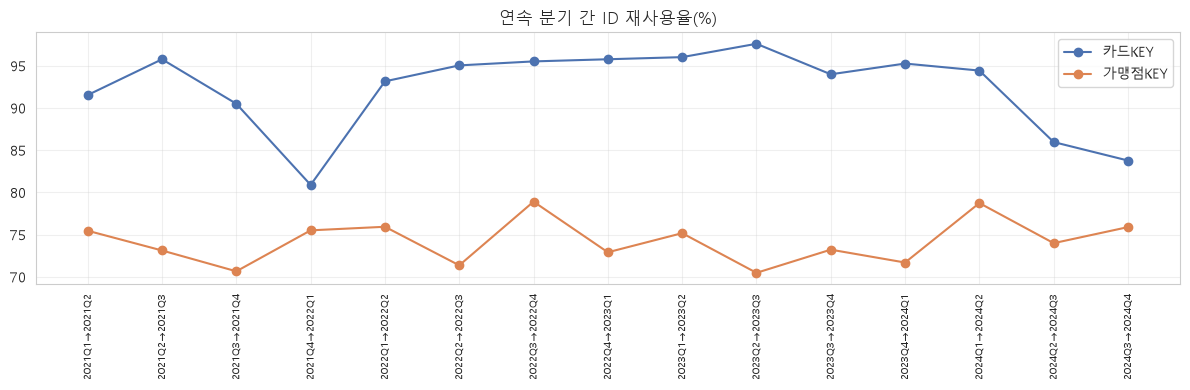

In [42]:
df['분기'] = df['거래연월'].dt.year.astype(str) + 'Q' + df['거래연월'].dt.quarter.astype(str)
quarters = sorted(df['분기'].unique())

def consecutive_quarter_overlap(id_col):
    id_sets = {q: set(df.loc[df['분기'] == q, id_col]) for q in quarters}
    ratios = []
    for q1, q2 in zip(quarters[:-1], quarters[1:]):
        inter = len(id_sets[q1] & id_sets[q2])
        ratios.append(inter / len(id_sets[q1]) * 100)
    return pd.Series(ratios, index=[f'{q1}\u2192{q2}' for q1, q2 in zip(quarters[:-1], quarters[1:])])

card_overlap = consecutive_quarter_overlap('카드KEY')
merchant_overlap = consecutive_quarter_overlap('가맹점KEY')

print(f"연속 분기 간 카드KEY 재사용율: 평균 {card_overlap.mean():.1f}% (최소 {card_overlap.min():.1f}%, 최대 {card_overlap.max():.1f}%)")
print(f"연속 분기 간 가맹점KEY 재사용율: 평균 {merchant_overlap.mean():.1f}% (최소 {merchant_overlap.min():.1f}%, 최대 {merchant_overlap.max():.1f}%)")

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(card_overlap.index, card_overlap.values, marker='o', label='카드KEY', color='#4C72B0')
ax.plot(merchant_overlap.index, merchant_overlap.values, marker='o', label='가맹점KEY', color='#DD8452')
ax.set_title('연속 분기 간 ID 재사용율(%)')
ax.tick_params(axis='x', rotation=90, labelsize=7)
ax.legend()
plt.tight_layout()
plt.show()



**해석**
- **카드KEY**는 연속 분기 간 평균 **92.3%**(최소 80.9%, 최대 97.6%)가 재사용되어, "약 90% 이상 재사용"이라는 표현이 대체로 타당합니다.
- 반면 **가맹점KEY**는 평균 **74.2%**(최소 70.5%, 최대 78.9%)로 카드보다 재사용률이 낮습니다 — 신규 가맹점 유입/폐업 회전이 카드 발급·해지보다 빠른 것으로 보입니다. "주요 인사이트"의 "카드/가맹점 ID가 약 90% 이상 재사용된다"는 서술은 카드에는 맞지만 가맹점에는 맞지 않아, 아래 요약에서 두 값을 구분해 정정했습니다.


## 주요 인사이트

1. **데이터 규모와 구조**: 2021~2024년 4개년, 16개 분기 파일이 동일한 32컬럼 스키마로 총 173만여 건 통합되었으며, 11절에서 확인했듯 **카드KEY는 분기를 넘어 평균 92.3%, 가맹점KEY는 평균 74.2%가 재사용되는 종단(longitudinal) 패널 데이터**입니다. 4년치 시계열이 확보되어 있어 계절성·추세 분석에 유리합니다.
2. **개인카드 중심 데이터**: 전체 거래의 약 90%가 개인카드, 10%만 법인카드입니다. 법인카드 정산 자동화가 목표라면, **이 데이터의 대부분은 직접적인 타깃 도메인이 아니며 참고·보조 자료로 취급**해야 합니다.
3. **거래금액 자체가 이미 강력한 신호이지만, "본인 평소 대비 급증"이 더 강력합니다**: 원본 `통합승인금액`과 이상거래여부의 상관계수가 0.71에 달할 만큼 금액 자체도 강력한 예측 변수였습니다. 그러나 카드별 개인화 Z-score 기준으로 보면 이상거래 비율이 2.4%→80.7%까지 뛰어, **"전체 대비 고액"보다 "본인 평소 대비 급증"이 한층 더 날카로운 신호**임을 확인했습니다. 다만 이 Z-score는 전체 기간 통계를 사용한 사후 계산값이라 데이터 누수가 있으므로(8절 참고), 실제 적용 전 Expanding Window 방식 재계산이 필요하며, 원본 금액에 대한 의존도가 워낙 높아 모델이 저액 이상거래를 놓치지 않도록 맥락 피처를 함께 설계해야 합니다.
4. **법인카드 관련 필드의 신뢰도 이슈**: `카드이용한도금액`은 법인카드 거래의 약 98%가 0원(미기재)으로 기록되어 있고, `남녀구분코드` 등 인적정보 필드도 법인카드에서는 `'_'`(해당없음)로 일괄 처리됩니다. 6-1·8-7절에서 확인했듯 **법인카드는 전체 이상거래 발생률이 개인카드의 절반 이하(1.52% vs 3.92%)로 낮지만, 발생 시 고액·개인화 Z-score 급증 구간에 거의 예외 없이 몰려 있고 야간 거래 신호의 방향까지 개인카드와 반대**여서, 개인카드와 다른 전처리·규칙 전략이 필요합니다.
5. **라벨의 성격 차이**: `이상거래여부`/`이상거래유형`은 카드사(발급사) 관점의 부정사용 탐지 라벨로, 8-8절에서 확인했듯 4개 코드값(3.0/5.0/9.0/17.0)은 금액대·업종이 서로 크게 다른 이질적인 유형들입니다(예: 유형 5.0은 평균 8,806원의 소액·단일 업종 반복 패턴으로, "고액=이상거래"라는 결론이 적용되지 않습니다). 요구사항 문서상 4가지 유형(카드 위변조, 현금융통, 유사수신, 전자상거래 허위매출)에 대응하는 것으로 보이나 코드-명칭 매핑표가 없어 확정하지 못했으며, 어느 경우든 법인카드 정산 담당자가 실제로 판단해야 할 "사규 위반·사적 사용·증빙 누락" 등과는 결이 다릅니다.

## 데이터 품질 문제

- 문자열 컬럼의 `'_'` 값은 `.isnull()`로 잡히지 않는 **은닉된 결측치**이며, 특히 법인카드 거래에서 인적정보 필드에 체계적으로 나타납니다 → 전처리 단계에서 명시적으로 NaN 변환 필요.
- `카드이용한도금액`은 사실상 4단계 구간 코드로, 연속형처럼 다루면 해석이 왜곡됩니다.
- `통합승인금액=0원` 거래(2,509건)의 이상거래 비율은 0.52%로 오히려 평균(3.69%)보다 낮아, 취소·인증성 거래로 보이며 이상거래 신호로 보기는 어렵습니다.
- `전월_매출건수` 음수(432건)의 이상거래 비율은 11.57%로 평균의 3배 이상이고, `전월_매출금액` 음수(936건)도 4.59%로 다소 높습니다 — 단순 데이터 오류로만 보기보다 위험 신호 피처 후보로 검토할 필요가 있습니다.
- `가맹점광역시도코드`, `가맹점승인업종코드`는 코드북(코드-명칭 매핑표)이 없어 실제 의미 해석이 제한적입니다.

## Feature Engineering 아이디어

- (본 노트북에서 구현) 거래요일/시간대구간, 월말여부, 사용자평균사용액, 가맹점평균금액, 최근7일사용횟수, 카드누적사용액, 개인화 거래금액 Z-score
- (추가 제안) 카드이용한도금액 대비 누적사용액 비율(한도소진율, 법인카드는 한도 신뢰도 이슈로 개인카드 우선 적용), 가맹점별 신규 여부·업종코드를 활용한 "저빈도 가맹점 + 고액결제" 조합 플래그, 동일 사용자의 최근 N건 대비 금액 증가율, 심야·주말 여부와 고액여부의 교차(조합) 피처, 동일 가맹점에서 여러 카드가 짧은 시간에 몰리는 패턴(가맹점 관점 이상탐지 피처)

## 모델링 방향

1. **1차: 규칙 기반(Rule Engine)** — 8절에서 탐색된 임계값(고액 상위 5%, 개인화 Z-score > 3 등)을 활용한 명시적 룰로 우선 스크리닝. 정산 담당자가 룰의 근거를 그대로 설명할 수 있어 **설명 가능성**과 국내 금융 규제상 사람이 최종 판단하는 구조에 부합합니다.
2. **2차: 지도학습 리스크 스코어링** — 클래스 불균형(약 26:1)을 고려해 class_weight/샘플링 기법을 적용한 트리 기반 앙상블(LightGBM/XGBoost). 단, 카드사 라벨을 그대로 쓰기보다 내부 정산 기준에 맞게 재정의하거나 참고 피처로 격하하는 것을 권장합니다.
3. **3차/보완: 비지도 이상탐지** — 내부 라벨이 부족한 Cold Start 구간에서는 Isolation Forest, Local Outlier Factor, DBSCAN 등으로 1차 스크리닝 후 사람이 검토·라벨링하며 지도학습으로 점진 전환.
4. 최종 판단은 반드시 **정산 담당자(사람)의 승인**을 거치도록 설계하여, ML/규칙 엔진은 "위험도 스코어 + 근거 제시(RAG 기반 justification)"까지만 담당하는 구조를 유지합니다.

## 추가 확보하면 좋은 데이터

- **실제 법인카드 정산 담당자의 승인/반려 이력** (진짜 타깃 라벨) — 가장 우선순위가 높습니다.
- 가맹점광역시도코드·업종코드에 대한 **코드북(코드-명칭 매핑표)** — 특히 `이상거래유형` 4개 코드값의 실제 명칭 확인에 필요합니다.
- 법인카드의 **한도 정보(정확한 값)** 및 **사용 목적/증빙(전자결재, 지출결의서 등) 연계 데이터**
- 조직 내 **사용자-부서-직급 정보** (동일 부서/직급 내 정상 지출 패턴과의 비교가 가능해짐)
- 반려/재검토 사례에 대한 **정산 담당자의 반려 사유 텍스트** (RAG 기반 근거 생성 모델 학습에 활용 가능)
